# **Advanced Genomics Project 2025/2026**

**Project 5:** DNA replication introduces copy number variations that are detectable in RNA-seq

**Authors:** Andrine Mykjåland Risøy, Georgia Manioudaki, Francesco Giuseppe Tagliabue

---

# Project outline:

* **1. Background**
  * 1.1. Mathematical framework

* **2. Project aims**

* **3. Data loading and preprocessing**
  * 3.1. Global settings
  * 3.2. Environment and dependencies
  * 3.3. Data loading
  * 3.4. Sample filtering and strain subsetting
  * 3.5. Genomic coordinate mapping
  * 3.6. Genomic windowing
  * 3.7. Expression scaling

* **4. Harmonic regression model**
  * 4.1. Fitting functions
  * 4.2. Harmonics fitting on logTPM expression
  * 4.3. Harmonics fitting on scaled expression

* **5. Growth rate prediction**
  * 5.1. Model fitting vs growth rate visualization
  * 5.2. Helmstetter-Cooper validation
  * 5.3. Model fitting vs growth rate correlation
  * 5.4. Growth rate regression

* **6. Gene-specific growth rate regression**
  * 6.1. Growth rate MLP regression
  * 6.2. MLP model interpretability

* **7. Discussion**
  * 7.1. Limitations
  * 7.2. Conclusion

---

# 1. Background

Circular bacterial chromosomes replication starts from a specific locus called origin of replication (*oriC*), proceeding in both directions until the replication forks meet at the terminus (*terC*). In E.coli, it is expected for the chromosome replication process to take about 40 minutes given a speed of the DNA polymerase $\approx 1000\text{ nt/s}$ and a chromosome arm ~2 million nucleotides (Helmstetter and Cooper, 1968). When a bacteria grows fast, their doubling time may be shorter than the expected 40 min, which means that a new round of replication has to start before the previous one is done. Because genes near the *oriC* get copied first and more times per division, we can expect that fast growing bacteria end up with more DNA copies for the genes near the *oriC*. More DNA copies may typically indicate more transcription leading to a possibly detectable dosage effect in the mRNA levels. On average we would expect to see a higher expression for these genes near the origin compared to the genes near the terminus. In this project, we will try to detect this gradient. 

In 2022, a similar expression pattern in gene expression data was described, using single-cell RNA-seq in Escherichia coli (E.coli) and Staphylococcus aureus (S.aureus) populations (Pountain et al., 2022).

For this project we investigate whether this effect is also detectable in a large bulk RNA-seq dataset where the signal is averaged across a lot of cells.

## 1.1. Mathematical framework

### Gene copy number 

The gene copy number measures the physical number of DNA template copies of a gene per cell. Under stable exponential growth, relative copy number $n_a$ at position $p_a$ follows the Helmstetter-Cooper kinetics:

$$n_a = 2^{(p_a C + D)/\tau}$$

This says that genes near *oriC*, high $p_a$, will give more DNA templates that can be transcribed, leading to higher average mRNA levels near the origin.

### Spatial periodicity and harmonic functions

Gene positions along the circular chromosome are converted to angles in radians. Gene expression $y(\theta)$ across the chromosome is averaged in 100kb-wide windows and modeled as harmonic functions of this angle. Three models will be used:

$$y(\theta) = \alpha + \beta \cos(\theta) + \gamma \sin(\theta)$$

$$y(\theta) = \alpha + \beta \cos(\theta - \phi)$$

$$y(\theta) = \alpha + \gamma \sin(\theta - \phi)$$

Amplitude $A = \sqrt{\beta^2 + \gamma^2}$ (for the latter two models, equal either to $|\beta|$ or $|\gamma|$) tells us the overall size of the gradient of the expression. For the cosine model centered at the origin ($\phi = \theta_{\text{ori}}$), $\beta > 0$ indicates an active replication and faster growth, $\beta \approx 0$ indicates flat profile, meaning a slow growth or a stationary phase, and $\beta < 0$ indicates peak at *terC*, which may suggest starvation or a stress response.

### Reference Coordinate Alignment (Unaligned vs. *oriC*-Aligned)

Unaligned models (`cos @ start`, `sin @ start`) place the reference point at position $x_{start} = 0\text{ bp}, \phi_{start} = 0\text{ rad}$. By aligning coordinates to *oriC* (`cos @ oriC`, `sin @ oriC`) and placing *oriC* at the angle 0 we are able to reduce the single-term models from two parameters asking where is the peak and how big is it? to a single parameter asking how big is the ori-peak? This could increase the statistical power of our tests. 

# 2. Project aims:

1. **Signal extraction by genomic windowing**: We aim to extract a signal by windowing the gene coordinates of the circular chromosome. By doing this we may be able to reduce the transcriptional noise and test harmonic regression models across different conditions.

2. **Harmonic model comparison**: From the harmonic regression analysis, we will also inspect three different regression formulations: 

    * Full harmonic model
    * Cosine-only model
    * Sine-only model

    In this analysis the harmonic model is tested using different reference coordinate alignment: unaligned and *oriC*-aligned. We will also use both logTPM data and scaled expression data.

3. **Helmstetter-Cooper model**: Test if the fitted wave scales with growth rate as expected from the theory of Helmstetter-Cooper. 
4. **Growth rate imputation**: Lastly, the goal is to build a predictive regression model that link estimated transcriptomic parameters to known growth rates. From this we may impute the growth rate for unannotated metadata samples.

# 3. Data loading and preprocessing

## 3.1. Global settings

Below are defined some variables used throughout the project. We choose to use the each gene's midpoint as its representative genomic coordinate and a window size of $100\text{ kb}$. The midpoint is useful here because the analysis focuses on chromosome-scale position rather than transcription direction.

In [1]:
# Gene position considered relative to reference
ref_pos = "mid"

# Window size (bases)
window_size = 100_000

# Quantile of gene expression variance to be excluded (scaled expression only)
gene_var_threshold = 0.1

# Random state seed
random_state = 42

## 3.2. Environment and dependencies

The processing of data, model fitting and statistical comparisons performed throughout the project have been implemented using methods from the following libraries: 

In [2]:
# OS
import os
from pathlib import Path
from IPython import get_ipython

# Utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bioinformatics
import gffutils
from Bio import SeqIO

# Statistics
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import linregress

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 3.3. Data loading

Firstly, we need to load the dataset and genomic references.

The given dataset includes:

- `sample_table.csv`: Samples metadata, containing information about strain, growth rate etc.
- `log_tpm.csv`: Sample-wise gene expression matrix, already normalized in $log_2(TPM)$

To assign gene positions across the chromosome, a corresponding genomic reference is also needed. We retrieved references for each strain present in the dataset as made available by the National Center of Biotechnology Information (NCBI), and for each of the three we were able to recover, both genome annotations (in GFF format) and sequence (in FASTA format) were used for the analysis.

| Strain | NCBI RefSeq assembly |
| --- | --- |
| MG1655 | GCF_000005845.2 |
| BW25113 | GCF_000750555.1 |
| W3110 | GCF_000010245.2 |

Two additional strains (GMOS and DGF-298), although present in the dataset, are engineered strains for which we could not find any corresponding reference genome.

**Note:** Even though strain DGF-298 is known to be derived from W3110, using the latter reference for those samples was not considered as their genome is significantly smaller (non-necessary genomic material has been removed).

In [3]:
"""
Directories structure:
src/
    advanced_genomics_project.ipynb

data/
    data_coli_growth_rate/
        sample_table.csv
        log_tpm.csv
        
    ref_genome/
        GCF_000005845.2/
            GCF_000005845.2_genomic.gff
            GCF_000005845.2_genomic.fna
        
        GCF_000750555.1/
            GCF_000750555.1_genomic.gff
            GCF_000750555.1_genomic.fna

        GCF_000010245.2/
            GCF_000010245.2_genomic.gff
            GCF_000010245.2_genomic.fna
"""

# Navigate to current directory
try:
    notebook_path = get_ipython().run_line_magic("pwd", "")
    os.chdir(notebook_path)
except Exception as e:
    print("Error in changing directory:", e)

# Define working environment
data_dir = Path("../data")

# Import data
samples      = pd.read_csv(data_dir / "data_coli_growth_rate/sample_table.csv",
                           index_col = 0)
exprs_logtpm = pd.read_csv(data_dir / "data_coli_growth_rate/log_tpm.csv",
                           index_col = 0)

# Define strains and corresponding references
strains = {
    "MG1655":  "GCF_000005845.2",
    "BW25113": "GCF_000750555.1",
    "W3110":   "GCF_000010245.2",
    "GMOS":    "",
    "DGF-298": "",
}

# Get strains that have a reference genome
ref_assemblies = {strain: acc for strain, acc in strains.items() if acc}

# Import reference annotations
ref_anns = {}
for strain, ref_assembly in ref_assemblies.items():
    gff_file = data_dir / "ref_genome" / ref_assembly / f"{ref_assembly}_genomic.gff"
    ref_anns[strain] = gffutils.create_db(gff_file,
                                          dbfn = ":memory:", force = True, keep_order = True,
                                          merge_strategy = "merge", sort_attribute_values = True)

# Import reference sequences
ref_seqs = {}
for strain, ref_assembly in ref_assemblies.items():
    fna_file = data_dir / "ref_genome" / ref_assembly / f"{ref_assembly}_genomic.fna"
    ref_seqs[strain] = SeqIO.read(fna_file, "fasta").seq

After loading the necessary data, we can begin by inspecting some useful information, starting with strain distribution.

A total of five different strains is present in the dataset. said strains are not present equally, as shown below.

Unique Strain values:
['MG1655' 'BW25113' 'GMOS' 'DGF-298' 'W3110']


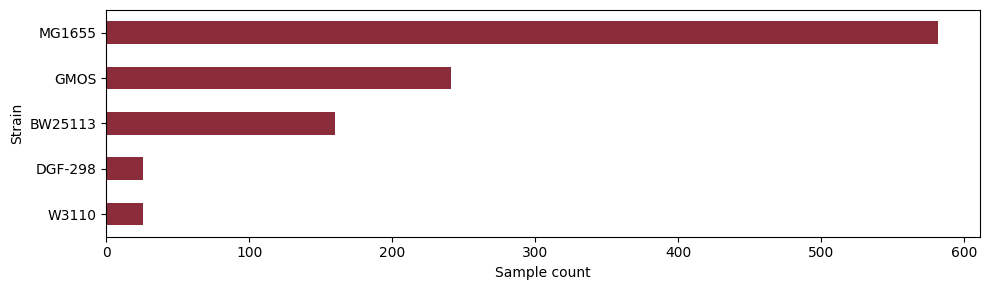

In [4]:
# Print different strains
print("Unique Strain values:")
print(samples["Strain"].unique())

# Plot strains distribution
fig, ax = plt.subplots(figsize = (10, 3))
samples["Strain"].value_counts(dropna = False).plot(kind = "barh", ax = ax, color = "#8b2c3a")
ax.set_xlabel("Sample count")
ax.set_ylabel("Strain")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The majority of samples belong to the MG1655 strain, with GMOS and BW25113 also having more than 100 samples each. Due to the fact that we do not have a reference annotation for the GMOS strain, however, we have to discard the corresponding samples from the harmonic fitting analyses.

We can proceed by inspecting growth rate distribution, as well as comparing it with carbon source information.

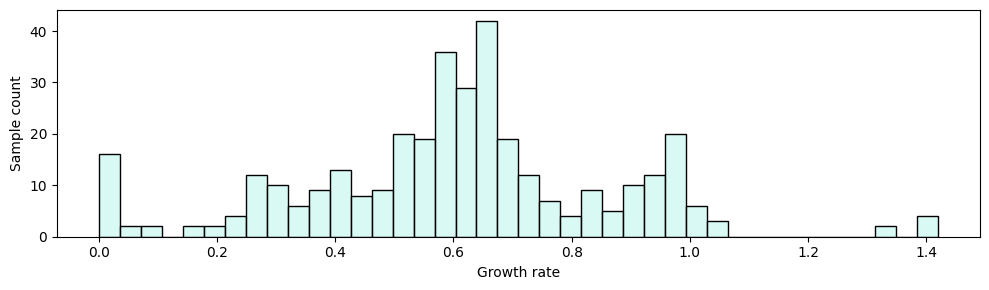

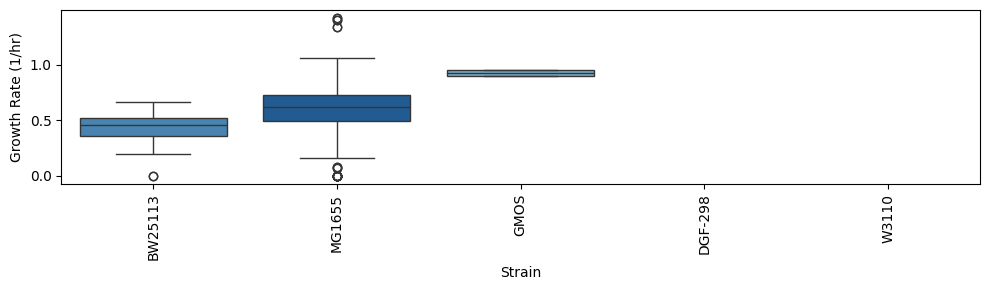

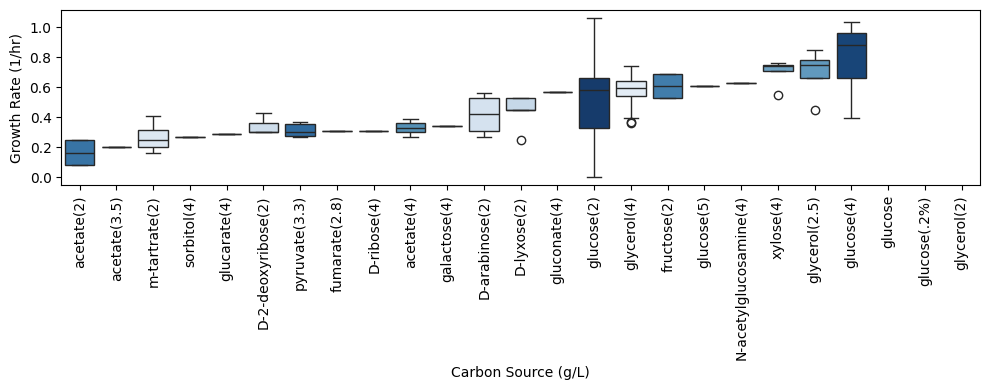

In [5]:
# Plot growth rate distribution
fig, ax = plt.subplots(figsize = (10, 3))
sns.histplot(samples["Growth Rate (1/hr)"], bins = 40, color = "#ccf7f1")
ax.set_xlabel("Growth rate")
ax.set_ylabel("Sample count")
plt.tight_layout()
plt.show()

# Plot growth rate vs strain
plt.figure(figsize = (10, 3))
order = samples.groupby("Strain")["Growth Rate (1/hr)"].median().sort_values().index
sns.boxplot(data = samples, x = "Strain", y = "Growth Rate (1/hr)",
            order = order,
            palette = "Blues_r",
            hue = "Strain", 
            legend = False)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

# Plot growth rate vs carbon source
plt.figure(figsize = (10, 4))
order = samples.groupby("Carbon Source (g/L)")["Growth Rate (1/hr)"].median().sort_values().index
sns.boxplot(data = samples, x = "Carbon Source (g/L)", y = "Growth Rate (1/hr)",
            order = order,
            palette = "Blues_r",
            hue = "Carbon Source (g/L)", 
            legend = False)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### **Observations:**

* Most samples have growth rates ranging between 0.3 and 1.0 h⁻¹, while there are only a few samples that show very high growth rates.
* MG1655 has many samples and covers the widest range of growth rates. Conversely, GMOS displays very limited wariation in growth rates.
* The growth rate seem to be dependent on carbon sources. Glucose-based conditions generally show higher growth rates, while acetate and other carbon sources are associated with slower growth.

## 3.4. Sample filtering and strain subsetting

We filter the expression matrix to match the corresponding reference data and ensure correct spatial alignment. As indicated in the project assignment, samples with growth rate assigned to 1 will be considered as unannotated.

In [6]:
# Initialize dictionaries
samples_str = {}
samples_str_ann = {}
exprs_logtpm_str = {}

# Iterate over strains
for strain in strains.keys():

    # Subset samples and expression
    samples_str[strain] = samples[samples["Strain"] == strain].copy()
    exprs_logtpm_str[strain] = exprs_logtpm[samples_str[strain].index.intersection(exprs_logtpm.columns)]

    # Replace growth rate == 1 with NaN
    placeholder_mask = samples_str[strain]["Growth Rate (1/hr)"] == 1
    samples_str[strain].loc[placeholder_mask, "Growth Rate (1/hr)"] = np.nan

    # Get samples with growth rate annotation
    samples_ann = samples_str[strain]["Growth Rate (1/hr)"].notna()

    # Add annotated samples
    if samples_ann.sum() > 0:
        samples_str_ann[strain] = samples_str[strain][samples_ann].copy()

    ref_note = "" if strains[strain] else "  [no reference genome]"
    print(f"{exprs_logtpm_str[strain].shape[1]} {strain} samples retained "
          f"({100 * exprs_logtpm_str[strain].shape[1] / exprs_logtpm.shape[1]:.1f}% of total samples), "
          f"{samples_ann.sum()} with annotated growth rate{ref_note}")

582 MG1655 samples retained (56.2% of total samples), 321 with annotated growth rate
160 BW25113 samples retained (15.5% of total samples), 24 with annotated growth rate
26 W3110 samples retained (2.5% of total samples), 0 with annotated growth rate
241 GMOS samples retained (23.3% of total samples), 8 with annotated growth rate  [no reference genome]
26 DGF-298 samples retained (2.5% of total samples), 0 with annotated growth rate  [no reference genome]


We can notice how only a significantly smaller population of the total amount of samples are annotated for growth rate. In particular, even though the GMOS strain has over 200 samples, only 8 of those have such information. For this reason, the only strains for which we deemed reasonable to consider growth rate information for subsequent analyses are MG1655 and BW25113.

We can now inspect growth rate and carbon source distributions by strain.

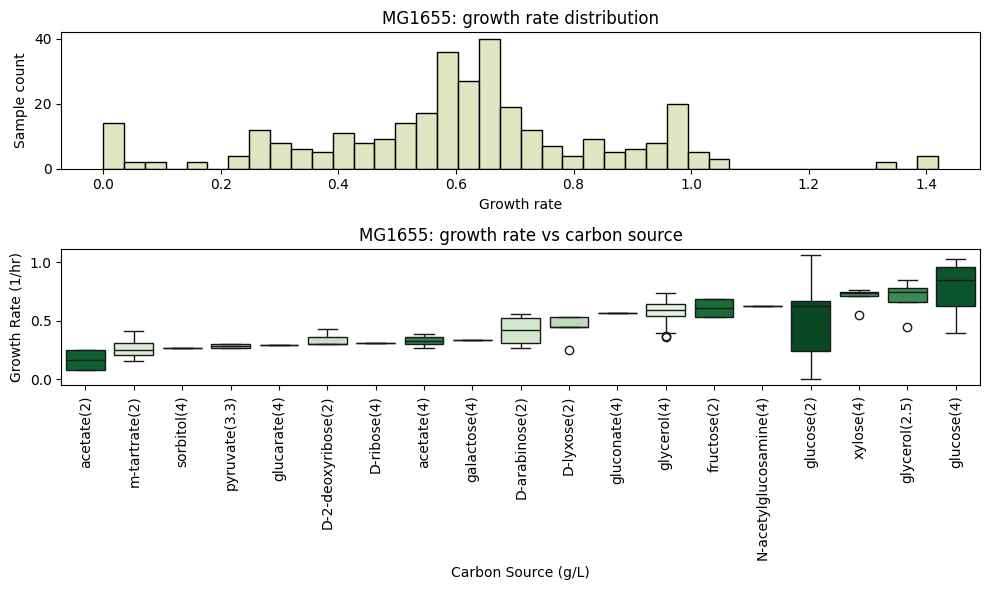

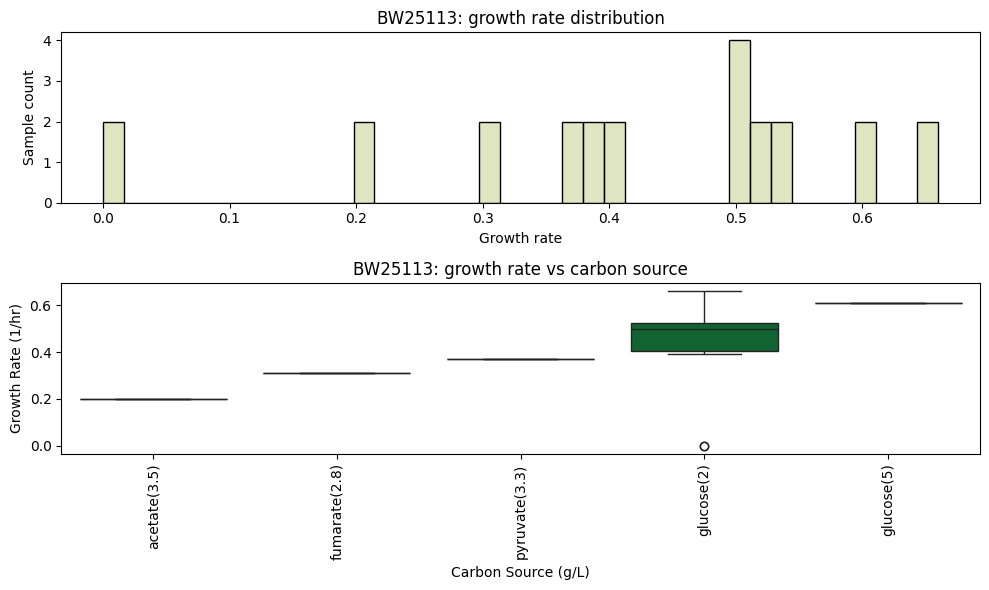

W3110: no samples with a valid growth rate annotation


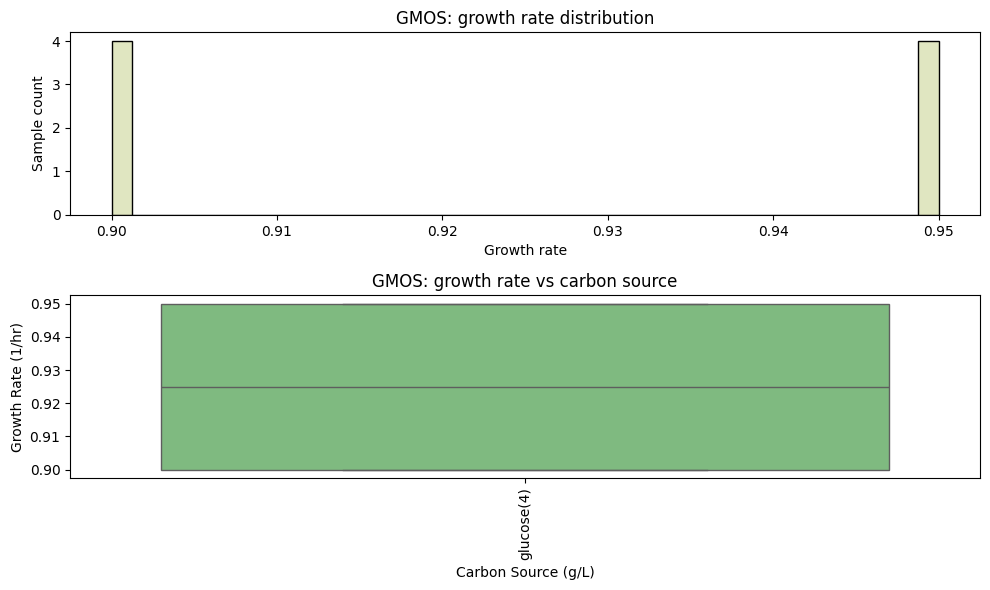

DGF-298: no samples with a valid growth rate annotation


In [7]:
# Plot growth rate distribution and vs carbon source per strain
for strain, s_str in samples_str.items():
    gr = s_str["Growth Rate (1/hr)"]

    if gr.notna().sum() == 0:
        print(f"{strain}: no samples with a valid growth rate annotation")
        continue

    order = s_str.groupby("Carbon Source (g/L)")["Growth Rate (1/hr)"].median().dropna().sort_values().index

    if len(order) == 0:
        print(f"{strain}: no carbon-source groups with a valid growth rate")
        continue

    fig = plt.figure(figsize = (10, 6))

    ax_hist = fig.add_subplot(2, 1, 1)
    sns.histplot(gr, bins = 40, ax = ax_hist, color = "#D6DEAD")
    ax_hist.set_xlabel("Growth rate")
    ax_hist.set_ylabel("Sample count")
    ax_hist.set_title(f"{strain}: growth rate distribution")

    ax_box = fig.add_subplot(2, 1, 2)
    sns.boxplot(data = s_str, x = "Carbon Source (g/L)", y = "Growth Rate (1/hr)",
               order = order, palette = "Greens_r", hue = "Carbon Source (g/L)", legend = False, ax = ax_box)
    ax_box.set_title(f"{strain}: growth rate vs carbon source")
    ax_box.tick_params(axis = "x", rotation = 90)

    plt.tight_layout()
    plt.show()

### **Observations:**

* The MG1655 cohort dominates the data set: 582 samples and a wide spectrum of growth rates ($\mu \approx 0.0\text{ to }1.4\text{ h}^{-1}$), where the growth rate correlates with the carbon source quality.
* The BW25113 cohort shows a more moderate growth rate distribution ($\mu \approx 0.2\text{ to }0.65\text{ h}^{-1}$), primarily across glucose substrates, and a total of 160 samples.

## 3.5. Genomic coordinate mapping

We now proceed to add positional information obtained from reference annotations and sequences. Since only three strains have a corresponding reference genome, the following steps will be performed only on such samples.

### Identify origin of replication (*oriC*)

The origin of replication is annotated only on the genome reference for the MG1655 strain. Since it is a highly conserved region across different lines, we can recover its location on the other two reference genomes by searching for it on the corresponding FASTA files.

First, we extract the feature from the MG1655 annotation.

In [8]:
# Get MG1655 origin_of_replication annotation
ori_feat_MG1655 = next(ref_anns["MG1655"].features_of_type("origin_of_replication"))

print(ori_feat_MG1655)
print(ori_feat_MG1655.attributes)

NC_000913.3	RefSeq	origin_of_replication	3925744	3925975	.	+	.	ID=id-NC_000913.3:3925744..3925975;gbkey=rep_origin;Note=oriC
ID: ['id-NC_000913.3:3925744..3925975']
Note: ['oriC']
gbkey: ['rep_origin']


As expected, one and only one feature is annotated as origin of replication (*oriC*).

We can then extract the sequence of the region 3925744-3925975 from strain MG1655 genome reference.

In [9]:
# Get MG1655 *oriC* sequence using known coordinates
ori_seq = ref_seqs["MG1655"][ori_feat_MG1655.start - 1 : ori_feat_MG1655.end]

print(f"*oriC* length: {len(ori_seq)} bp")
print(ori_seq)

*oriC* length: 232 bp
GATCTATTTATTTAGAGATCTGTTCTATTGTGATCTCTTATTAGGATCGCACTGCCCTGTGGATAACAAGGATCCGGCTTTTAAGATCAACAACCTGGAAAGGATCATTAACTGTGAATGATCGGTGATCCTGGACCGTATAAGCTGGGATCAGAATGAGGGGTTATACACAACTCAAAAACTGAACAACAGTTGTTCTTTGGATAACTACCGGTTGATCCAAGCTTCCTGA


We have now obtained the sequence that we will need to look for in the other references.

We now prepare the function used for finding a query sequence inside a reference. In order to avoid ambiguity, we ensure it will run into an error in case it is not possible to find one and only one match.

In [10]:
def find_seq(genome_seq, query_seq):

    query_str = str(query_seq)
    rc_query_str = str(query_seq.reverse_complement())
    genome_str = str(genome_seq)

    # Get counts of matches on forward and reverse strand
    n_fwd = genome_str.count(query_str)
    n_rev = genome_str.count(rc_query_str)

    # Verify that one and only one match exists
    assert n_fwd + n_rev == 1, (
        f"Expected exactly 1 match, found {n_fwd} forward and {n_rev} reverse"
    )

    if n_fwd == 1:

        # Match found on forward strand
        pos = genome_str.find(query_str)
        print(f"Exact match on forward strand at {pos + 1}-{pos + len(query_str)}")
        return pos + 1, pos + len(query_str), "+"
    
    else:

        # Match found on reverse strand
        pos = genome_str.find(rc_query_str)
        print(f"Exact match on reverse strand at {pos + 1}-{pos + len(query_str)}")
        return pos + 1, pos + len(query_str), "-"

### Genome Positioning

Inside `log_tpm.csv`, all genes are indexed by their MG1655 b-number (e.g. `b0002`) regardless of
the actual strain of origin. However, each strain's own GFF annotation uses its own locus_tag naming convention:
MG1655 locus tags are the b-numbers, but BW25113 and W3110 use separate,
strain-specific RefSeq tags (*e.g.*, `BW25113_RS02415`, `Y75_RS02405`) that never appear in
the original expression matrix.

To fix this, we use each gene's gene symbol (e.g. `priC`), which is consistent across strains,
to translate BW25113/W3110 genes back into b-number space via a symbol to b-number mapping
built from the MG1655 annotation, before joining against the expression matrix.

In [11]:
# Build gene symbol to b-number mapping from MG1655 annotation
symbol_MG1655_to_bnum = {}
for feat in ref_anns["MG1655"].all_features(featuretype = "gene"):
    locus_tag = feat.attributes.get("locus_tag", [None])[0]
    gene_symbol = feat.attributes.get("gene", [None])[0]
    if locus_tag and gene_symbol:
        symbol_MG1655_to_bnum[gene_symbol] = locus_tag

print(f"{len(symbol_MG1655_to_bnum)} MG1655 genes with a gene symbol available for cross-strain mapping")

4506 MG1655 genes with a gene symbol available for cross-strain mapping


After finding each gene's own starting and ending position from the reference annotation, gene midpoints are converted into circular angular coordinates:

$$\text{rad} = \frac{2\pi \cdot X_i}{\text{Genome Length}}$$

The origin of replication *oriC* angle (`ori_rad`) is found from its base pair midpoint (`ori_bp`):

$$\text{ori\_rad} = \frac{2\pi \cdot \text{ori\_bp}}{\text{Genome Length}}$$

Since it was not annotated in any of the found references, the replication terminus *terC* is defined as the genomic coordinate directly opposite of *oriC* (`ter_rad`):

$$\text{ter\_rad} = (\text{ori\_rad} + \pi)$$

We define a function to build genome reference information for each of our strains.

In [12]:
def build_reference(ref_ann, ref_seq, ori_seq,
                    gene_id_map = None):

    # Get genome length
    genome_length = len(ref_seq)

    # Get gene positions
    records = []
    for feat in ref_ann.all_features(featuretype = "gene"):
        locus_tag = feat.attributes.get("locus_tag", [None])[0]
        gene_symbol = feat.attributes.get("gene", [None])[0]

        if gene_id_map is not None:

            # Get corresponding gene
            gene_id = gene_id_map.get(gene_symbol)
            
        else:

            # MG1655: locus_tag already is the b-number
            gene_id = locus_tag

        if gene_id:
            records.append({
                "gene_id": gene_id,
                "start": feat.start, "end": feat.end,
                "mid": (feat.start + feat.end) / 2,
                "strand": feat.strand
            })

    gene_pos = pd.DataFrame(records).set_index("gene_id")
    gene_pos = gene_pos[~gene_pos.index.duplicated(keep = "first")]

    # Add 5' end
    gene_pos["bio_start"] = gene_pos.apply(lambda r: r["start"] if r["strand"] == "+" else r["end"], axis = 1)

    # Add 3' end
    gene_pos["bio_end"]   = gene_pos.apply(lambda r: r["end"]   if r["strand"] == "+" else r["start"], axis = 1)

    # Get *oriC* from reference
    ori_loc = find_seq(ref_seq, ori_seq)
    ori_bp = (ori_loc[0] + ori_loc[1]) / 2

    # Define *terC* as the antipodal location on the chromosome
    ter_bp = (ori_bp + genome_length / 2) % genome_length

    return {
        "genome_length": genome_length,
        "gene_pos": gene_pos,
        "ori_bp": ori_bp,
        "ter_bp": ter_bp,
        "ori_rad": 2 * np.pi * ori_bp / genome_length,
        "ter_rad": 2 * np.pi * ter_bp / genome_length
    }

# Initialize dictionary
ref_builds = {}

for strain in ref_assemblies.keys():
    if strain == "MG1655":
        ref_builds[strain] = build_reference(ref_anns[strain], ref_seqs[strain], ori_seq)
    else:
        ref_builds[strain] = build_reference(ref_anns[strain], ref_seqs[strain], ori_seq,
                                             gene_id_map = symbol_MG1655_to_bnum)

    ref = ref_builds[strain]
    print(f"{strain}: genome_length = {ref["genome_length"]}, "
          f"{len(ref['gene_pos'])} genes mapped to compendium IDs, *oriC* = {ref["ori_bp"]:.0f} bp")

Exact match on forward strand at 3925744-3925975
MG1655: genome_length = 4641652, 4506 genes mapped to compendium IDs, *oriC* = 3925860 bp
Exact match on forward strand at 3919104-3919335
BW25113: genome_length = 4631469, 3926 genes mapped to compendium IDs, *oriC* = 3919220 bp
Exact match on reverse strand at 3710706-3710937
W3110: genome_length = 4646332, 3915 genes mapped to compendium IDs, *oriC* = 3710822 bp


We observe how only one match of *oriC* is correctly identified in each of the given strain references, with BW25113 having it located on the forward strand and W3110 on the reverse strand. Overall, genome lenghts are very close between each others.

We can then inspect the gene distribution across each of the references.

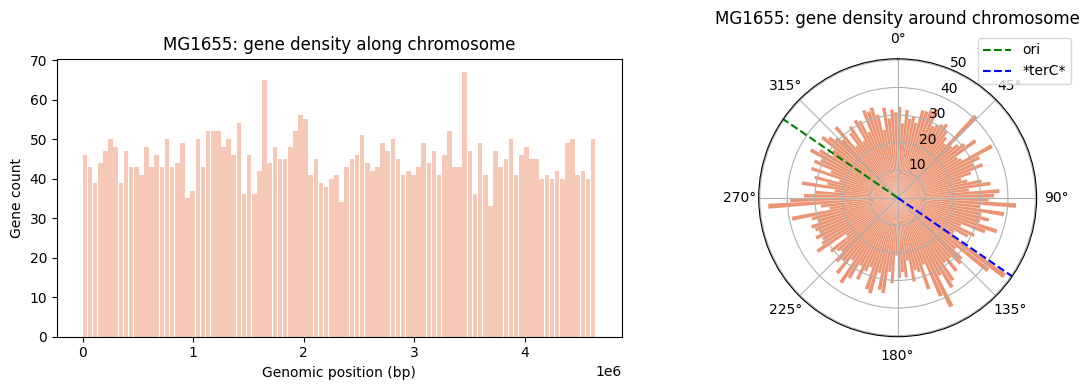

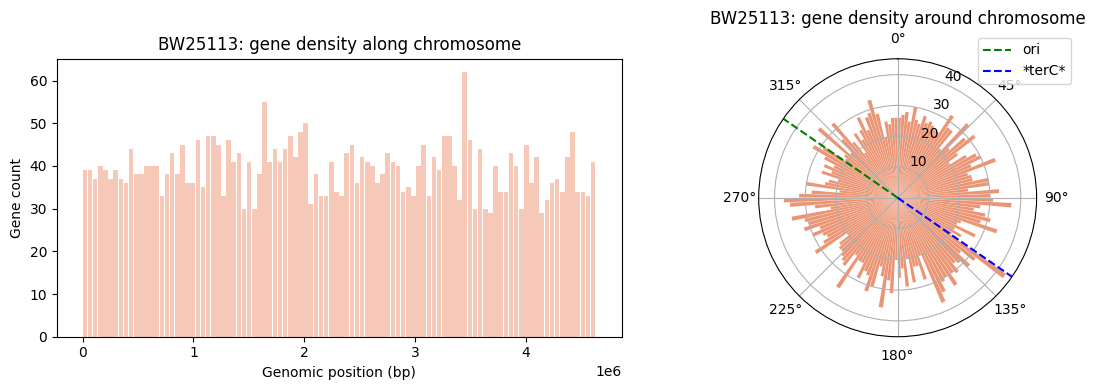

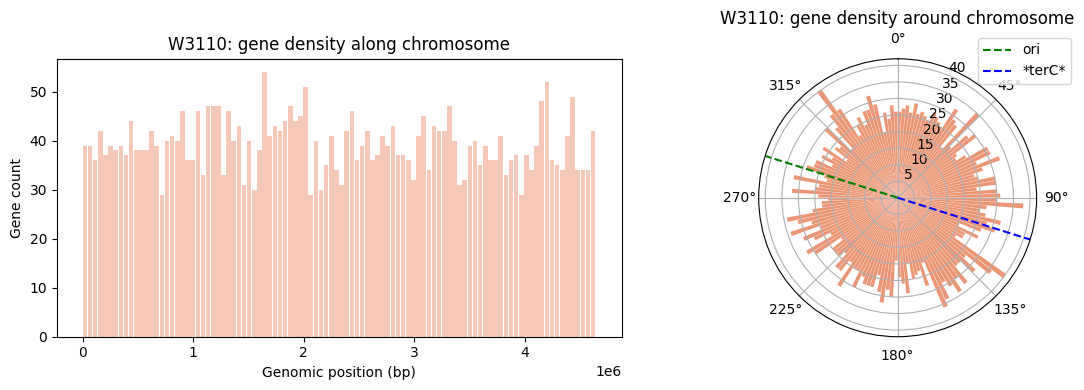

In [13]:
# Plot gene density (linear + circular) per strain
for strain, ref in ref_builds.items():
    gene_pos = ref["gene_pos"]
    genome_length = ref["genome_length"]
    ori_rad, ter_rad = ref["ori_rad"], ref["ter_rad"]

    fig = plt.figure(figsize = (12, 4))

    ax_lin = fig.add_subplot(1, 2, 1)
    ax_lin.hist(gene_pos[ref_pos], bins = 100,
                width = genome_length / 100 * 0.9, color = "#f5c8b7")
    ax_lin.set_xlabel("Genomic position (bp)")
    ax_lin.set_ylabel("Gene count")
    ax_lin.set_title(f"{strain}: gene density along chromosome")

    ax_polar = fig.add_subplot(1, 2, 2, projection = "polar")
    ax_polar.axvline(ori_rad, color = "green", ls = "--", lw = 1.5, label = "ori")
    ax_polar.axvline(ter_rad, color = "blue", ls = "--", lw = 1.5, label = "*terC*")

    rad = 2 * np.pi * gene_pos[ref_pos] / genome_length
    n_bins = 144
    counts, bin_edges = np.histogram(rad, bins = n_bins, range = (0, 2 * np.pi))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = 2 * np.pi / n_bins * 0.9

    ax_polar.bar(bin_centers, counts, width = width, color = "#ec9574")
    ax_polar.set_theta_zero_location("N")
    ax_polar.set_theta_direction(-1)
    ax_polar.set_title(f"{strain}: gene density around chromosome")
    ax_polar.legend(loc = "upper right", bbox_to_anchor = (1.15, 1.1))

    plt.tight_layout()
    plt.show()

### **Observations:**

* **MG1655 cohort:**
  * Total genome length: $4,641,652\text{ bp}$
  * Total genes mapped: $4506$
  * Origin locus ($\text{ori\_bp}$): $3,925,860\text{ bp}$

* **BW25113 cohort:**
  * Total genome length: $4,631,469\text{ bp}$
  * Total genes mapped: $3926$
  * Origin locus ($\text{ori\_bp}$): $3,919,220\text{ bp}$

* **W3110 cohort:**
  * Total genome length: $4,646,332\text{ bp}$
  * Total genes mapped: $3915$
  * Origin locus ($\text{ori\_bp}$): $3,710,822\text{ bp}$

* Across all strains, gene density appears to have an even distribution, while *oriC* location sligthly differ from W3110 compared to the other two. In particular, we can notice how it approaches the 90°/270° axis in the polar plot, an observation which we will consider once more in the next analyses.

## 3.6. Genomic windowing

As previously mentioned, we group genes into windows of $100\text{ kb}$ to reduce noise. Then for each genomic window, the mean expression level is computed across the genes for each sample.
The expression levels are reported in $log_2(TPM)$ form, meaning that calculating the arithmetic mean in the log-space matches computing the log-transformed geometric mean in linear space.

In [14]:
# Initialize dictionary
window_data_logtpm = {}

# Build windows per strain
for strain, ref in ref_builds.items():

    # Get gene positions
    merged = exprs_logtpm_str[strain].join(ref["gene_pos"][[ref_pos]], how = "inner")

    # Assign windows
    merged["window"] = (merged[ref_pos] // window_size).astype(int)
    sample_cols = [c for c in merged.columns if c not in (ref_pos, "window")]

    # Add details
    window_expr = merged.groupby("window")[sample_cols].mean()
    window_rad = merged.groupby("window")[ref_pos].mean() * 2 * np.pi / ref["genome_length"]
    window_n_genes = merged.groupby("window").size()

    window_data_logtpm[strain] = {
        "window_expr": window_expr,
        "window_rad": window_rad,
        "window_n_genes": window_n_genes,
        "sample_cols": sample_cols
    }

    print(f"{strain}: {len(window_expr)} windows, "
          f"{window_n_genes.min()}-{window_n_genes.max()} genes per window")

MG1655: 47 windows, 42-111 genes per window
BW25113: 47 windows, 26-105 genes per window
W3110: 47 windows, 42-109 genes per window


Genomes have similar lenghts, so an equal amount of windows is produced from each strain. Moreover, the amount of genes per window ranges consistently across strain.

We now inspect the distribution of genes per window in each genome.

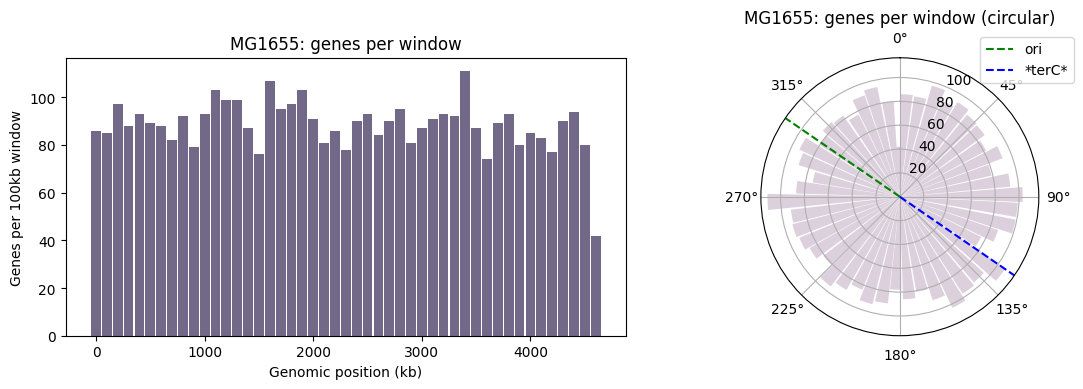

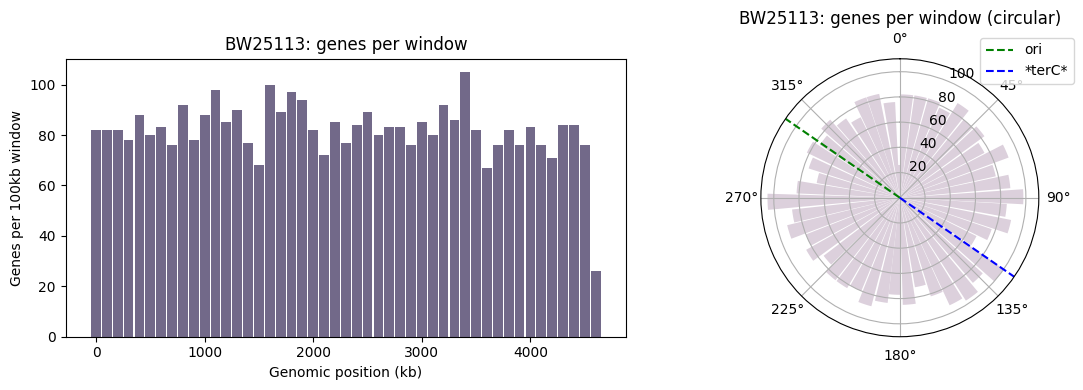

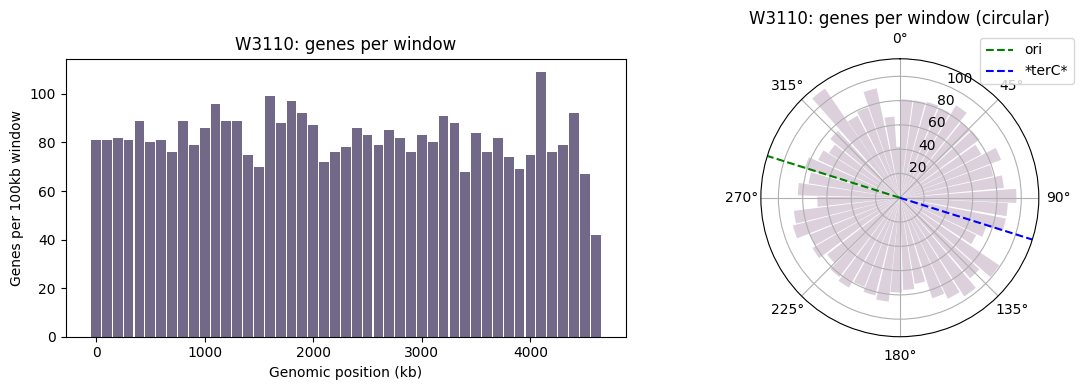

In [15]:
# Plot windows per strain
for strain, ref in ref_builds.items():
    wd = window_data_logtpm[strain]

    fig = plt.figure(figsize = (12, 4))

    ax_lin = fig.add_subplot(1, 2, 1)
    ax_lin.bar(wd["window_n_genes"].index * window_size / 1000, wd["window_n_genes"].values,
               width = window_size / 1000 * 0.9, color = "#726989", edgecolor = "none")
    ax_lin.set_xlabel("Genomic position (kb)")
    ax_lin.set_ylabel("Genes per 100kb window")
    ax_lin.set_title(f"{strain}: genes per window")

    ax_polar = fig.add_subplot(1, 2, 2, projection = "polar")
    ax_polar.axvline(ref["ori_rad"], color = "green", ls = "--", lw = 1.5, label = "ori")
    ax_polar.axvline(ref["ter_rad"], color = "blue", ls = "--", lw = 1.5, label = "*terC*")
    width = 2 * np.pi * window_size / ref["genome_length"] * 0.9
    ax_polar.bar(wd["window_rad"].values, wd["window_n_genes"].values,
                 width = width, color = "#dcd0dc", edgecolor = "none")
    ax_polar.set_theta_zero_location("N")
    ax_polar.set_theta_direction(-1)
    ax_polar.set_title(f"{strain}: genes per window (circular)")
    ax_polar.legend(loc = "upper right", bbox_to_anchor = (1.15, 1.1))

    plt.tight_layout()
    plt.show()

### **Observations**:

* **MG1655 Cohort**: Divided into 47 genomic windows consisting of between 42-111 genes.

* **BW25113 Cohort**: Divided into 47 genomic windows consisting of between 26-105 genes.

* **W3110 Cohort**: Divided into 47 genomic windows consisting of between 42-109 genes.

## 3.7. Expression scaling

As an additional step, some of the following analyses have been performed a second time on a reduced and scaled dataset. To prevent the dominating effect of highly expressed genes or genes with high variance, we standardize the gene expression profile across the samples. 

The standardization process includes the following steps: 

1. **Filtering of low-variance genes:** after calculating the standard deviation of expression for each gene across all samples, we remove the genes in the bottom 10% which would only add noise to the data.
2. **Z-score standardization:** The remaining genes's expressions are centered and rescaled to a mean $\mu = 0$ and standard deviation $\sigma = 1$. This was done to have a more consistent comparison between the alternating levels of expression of different genes.

In [16]:
# Initialize dictionaries
exprs_logtpm_str_sub = {}
exprs_scaled_str = {}

# Scale each strain's expression separately
for strain, e_str in exprs_logtpm_str.items():
    gene_stds = e_str.std(axis = 1)

    # Filter low variance genes
    std_threshold = gene_stds.quantile(gene_var_threshold)
    genes_to_keep = gene_stds[gene_stds > std_threshold].index
    e_filtered = e_str.loc[genes_to_keep]
    exprs_logtpm_str_sub[strain] = e_filtered

    # Center and scale expression
    gene_means_f = e_filtered.mean(axis = 1)
    gene_stds_f = e_filtered.std(axis = 1)
    exprs_scaled_str[strain] = e_filtered.sub(gene_means_f, axis = 0).div(gene_stds_f, axis = 0)

    print(f"{strain}: {len(genes_to_keep)} of {len(gene_stds)} genes retained after variance filtering")

MG1655: 3831 of 4257 genes retained after variance filtering
BW25113: 3831 of 4257 genes retained after variance filtering
W3110: 3831 of 4257 genes retained after variance filtering
GMOS: 3831 of 4257 genes retained after variance filtering
DGF-298: 3821 of 4257 genes retained after variance filtering


Most genes across strains are retained after variance filtering.

We can then proceed by building windows for each strain for which we possess genomic reference information, using the same logic as before.

In [17]:
# Initialize dictionary
window_data_scaled = {}

# Build windows per strain
for strain, ref in ref_builds.items():

    # Get gene positions
    merged = exprs_scaled_str[strain].join(ref["gene_pos"][[ref_pos]], how = "inner")

    # Assign windows
    merged["window"] = (merged[ref_pos] // window_size).astype(int)
    sample_cols = [c for c in merged.columns if c not in (ref_pos, "window")]

    # Add details
    window_expr = merged.groupby("window")[sample_cols].mean()
    window_rad = merged.groupby("window")[ref_pos].mean() * 2 * np.pi / ref["genome_length"]
    window_n_genes = merged.groupby("window").size()

    window_data_scaled[strain] = {
        "window_expr": window_expr,
        "window_rad": window_rad,
        "window_n_genes": window_n_genes,
        "sample_cols": sample_cols
    }

    print(f"{strain}: {len(window_expr)} windows, "
          f"{window_n_genes.min()}-{window_n_genes.max()} genes per window")

MG1655: 47 windows, 39-105 genes per window
BW25113: 47 windows, 24-94 genes per window
W3110: 47 windows, 36-99 genes per window


It is possible to notice how a lower range is consistently obtained for each strain compared to the case in wich we do not filter any feature.

We can now inspect gene distribution across the new windows.

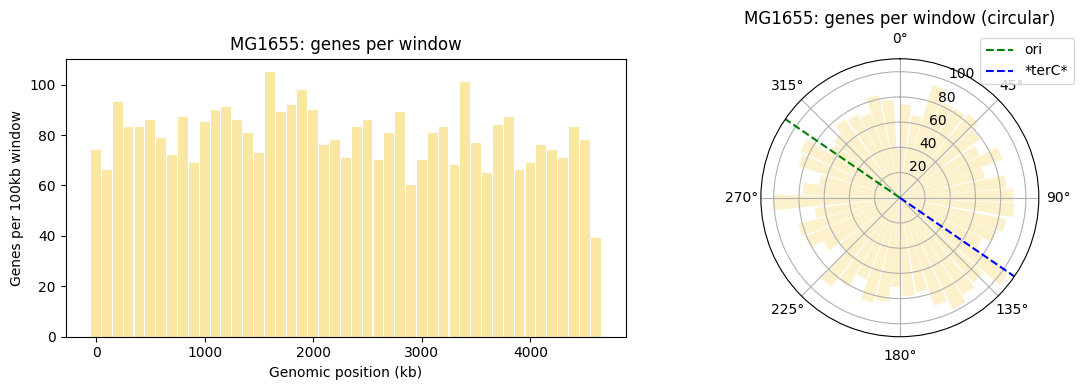

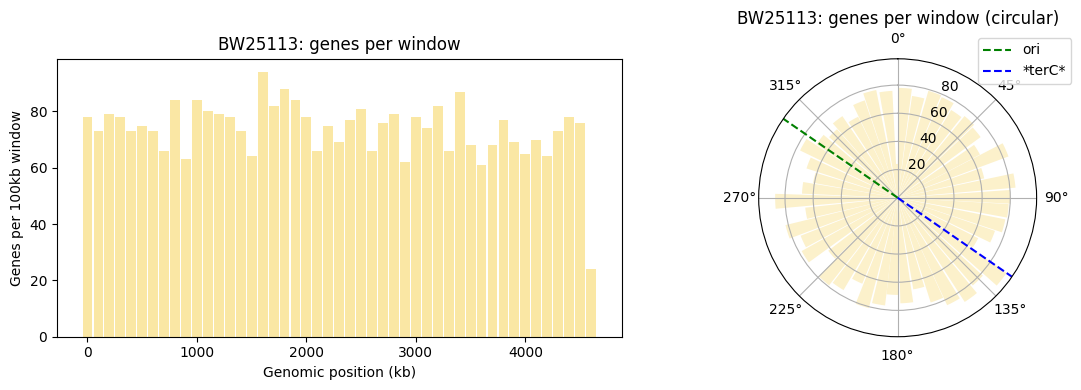

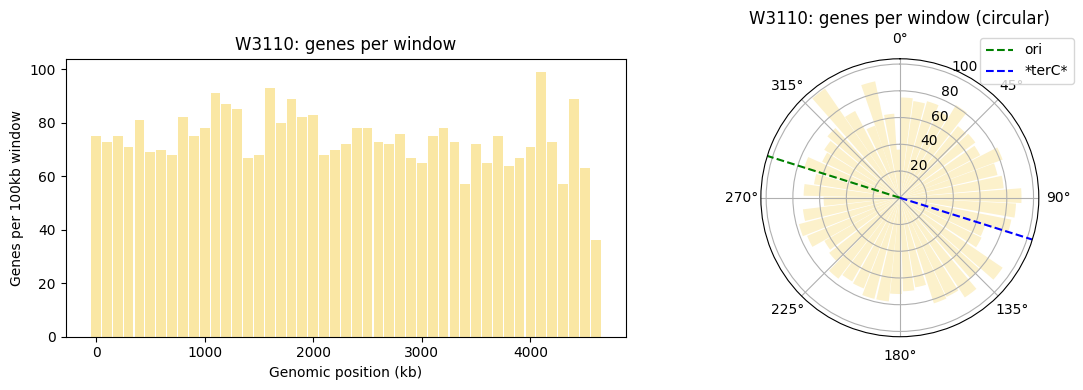

In [18]:
# Plot windows per strain
for strain, ref in ref_builds.items():
    wd = window_data_scaled[strain]

    fig = plt.figure(figsize = (12, 4))

    ax_lin = fig.add_subplot(1, 2, 1)
    ax_lin.bar(wd["window_n_genes"].index * window_size / 1000, wd["window_n_genes"].values,
               width = window_size / 1000 * 0.9, color = "#fae7a4", edgecolor = "none")
    ax_lin.set_xlabel("Genomic position (kb)")
    ax_lin.set_ylabel("Genes per 100kb window")
    ax_lin.set_title(f"{strain}: genes per window")

    ax_polar = fig.add_subplot(1, 2, 2, projection = "polar")
    ax_polar.axvline(ref["ori_rad"], color = "green", ls = "--", lw = 1.5, label = "ori")
    ax_polar.axvline(ref["ter_rad"], color = "blue", ls = "--", lw = 1.5, label = "*terC*")
    width = 2 * np.pi * window_size / ref["genome_length"] * 0.9
    ax_polar.bar(wd["window_rad"].values, wd["window_n_genes"].values,
                 width = width, color = "#fcf1cb", edgecolor = "none")
    ax_polar.set_theta_zero_location("N")
    ax_polar.set_theta_direction(-1)
    ax_polar.set_title(f"{strain}: genes per window (circular)")
    ax_polar.legend(loc = "upper right", bbox_to_anchor = (1.15, 1.1))

    plt.tight_layout()
    plt.show()

### **Observations**:

* **MG1655 cohort**: Divided into 47 genomic windows consiting of between 39-105 genes. 

* **BW25113 cohort**: Divided into 47 genomic windows consiting of between 24-94 genes.

* **W3110 cohort**: Divided into 47 genomic windows consiting of between 36-99 genes.

# 4. Harmonic regression model

For each sample, window-level expression is modelled as a function of chromosome position. Because the chromosome is circular, a harmonic model is suitable for describing a smooth pattern that changes around the chromosome and returns to the same point.

We first use the full cosine + sine model because it can detect a periodic pattern without assuming where the peak should be. We then use cosine-only and sine-only models to understand the direction of the signal. Later we shift the model so that *oriC* is used as the biological reference point.

The full model is:

$$y(\theta) = \alpha + \beta\cos(\theta) + \gamma\sin(\theta)$$

where:

- $y$ is the mean expression of a genomic window
- $\theta$ is the position of that window in radians
- $\alpha$ is the average fitted expression level
- $\beta$ and $\gamma$ describe the strength and position of the chromosome-wide pattern. Their values depend on where zero radians is placed. The amplitude A gives the overall strength of the periodic pattern, independent of its direction.

For such model, the signal amplitude can be obtained as:

$$A = \sqrt{\beta^2 + \gamma^2}$$

With this model, we can detect a periodic pattern even when the peak is not exactly aligned with the biological *oriC* phase. For each sample, from harmonics fitting we will retrieve coefficients, amplitude, peak position, R², F-statistic and corresponding p-value to measure the strength of the pattern and test whether it is statistically significant.

In this analysis we will be evaluating five harmonics models:

| Model | Function |
| --- | --- |
| Full model (`cos + sin`) | $y(\theta) = \alpha + \beta \cos(\theta) + \gamma \sin(\theta)$ |
| Cosine model, unaligned (`cos @ start`) | $y(\theta) = \alpha + \beta \cos(\theta)$ |
| Sine model, unaligned (`sin @ start`) | $y(\theta) = \alpha + \gamma \sin(\theta)$ |
| Cosine model, *oriC*-aligned (`cos @ oriC`) | $y(\theta) = \alpha + \beta \cos(\theta - \theta_{\text{ori}})$ |
| Sine model, *oriC*-aligned (`sin @ oriC`) | $y(\theta) = \alpha + \gamma \sin(\theta - \theta_{\text{ori}})$ |

Assuming the data actually follows the predicted biological curve peaking at *oriC* or *terC*, the two models we expect to have good fitting performance are `cos + sin` (unconstrained fit, expected peak around *oriC*/*terC*) and `cos @ oriC` (fixed phase at *oriC*).

## 4.1. Fitting functions

In this section, utility functions used to model, predict, and visualize the results are prepared.

We start with the harmonic fitting function. A single function is used for all harmonics chosen, changing the extracted terms from the dataset depending on the parameters given.

In [19]:
# Fitting function
def fit_harmonic(y, rad,
                 terms = "both",
                 phase = 0):

    # Shift by phase
    shifted = rad - phase

    # Extract harmonics
    if terms == "both":
        X = np.column_stack([np.cos(shifted), np.sin(shifted)])

    elif terms == "cos":
        X = np.cos(shifted).reshape(-1, 1)

    elif terms == "sin":
        X = np.sin(shifted).reshape(-1, 1)
        
    else:
        raise ValueError("terms must be 'both', 'cos', or 'sin'")

    # Add intercept
    X = sm.add_constant(X)

    # Fit model (ordinary least squares)
    model = sm.OLS(y, X).fit()

    return model

A summarization function will return the results of interest after model fitting, adapting the computation of amplitude and peak position depending on the used terms.

- $y(\theta) = \alpha + \beta \cos(\theta) + \gamma \sin(\theta)$:

$$A = \sqrt{\beta^2 + \gamma^2}$$
$$\theta_{peak} = \text{atan2}(\gamma, \beta) \mod 2\pi$$

- $y(\theta) = \alpha + \beta \cos(\theta - \phi)$:
$$A = |\beta|$$
$$\theta_{peak} = \begin{cases} \phi & \text{if } \beta \geq 0 \\ \phi + \pi & \text{if } \beta < 0 \end{cases}$$

- $y(\theta) = \alpha + \gamma \sin(\theta - \phi)$:
$$A = |\gamma|$$
$$\theta_{peak} = \begin{cases} \phi + \pi/2 & \text{if } \gamma \geq 0 \\ \phi + 3\pi/2 & \text{if } \gamma < 0 \end{cases}$$

For single-term models, peak position can either be at the reference phase or exactly opposite it (cosine only), or a quarter-cycle offset from it (sine only).

In [20]:
def summarize_fit(model,
                  terms = "both",
                  phase = 0):
    
    if terms == "both":

        # y = alpha + beta * cos(rad) + gamma * sin(rad)
        alpha, beta, gamma = model.params

        # A = sqrt(beta^2 + gamma^2)
        amplitude = np.sqrt(beta**2 + gamma**2)

        peak_position_rad = np.arctan2(gamma, beta) % (2 * np.pi)

    elif terms == "cos":

        # y = alpha + beta * cos(rad)
        alpha, beta = model.params
        gamma = None

        # A = |beta|
        amplitude = abs(beta)

        base_peak = phase
        peak_position_rad = base_peak if beta >= 0 else base_peak + np.pi
        peak_position_rad = peak_position_rad % (2 * np.pi)

    elif terms == "sin":

        # y = alpha + gamma * sin(rad)
        alpha, gamma = model.params
        beta = None

        # A = |gamma|
        amplitude = abs(gamma)
        
        base_peak = phase + np.pi / 2
        peak_position_rad = base_peak if gamma >= 0 else base_peak + np.pi
        peak_position_rad = peak_position_rad % (2 * np.pi)
        
    else:
        raise ValueError("terms must be 'both', 'cos', or 'sin'")

    return {
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "amplitude": amplitude,
        "peak_position_rad": peak_position_rad,
        "f_stat": model.fvalue,
        "p_val": model.f_pvalue,
        "r2": model.rsquared
    }

A prediction function is also initialized, used after model fitting to inspect the fit of the harmonic.

In [21]:
def predict_curve(model, rad,
                  terms = "both",
                  phase = 0,
                  alpha = 0.05):

    # Shift by phase
    shifted = rad - phase

    # Extract harmonics
    if terms == "both":
        X = np.column_stack([np.cos(shifted), np.sin(shifted)])

    elif terms == "cos":
        X = np.cos(shifted).reshape(-1, 1)

    elif terms == "sin":
        X = np.sin(shifted).reshape(-1, 1)

    else:
        raise ValueError("terms must be 'both', 'cos', or 'sin'")

    # Add intercept
    X = sm.add_constant(X, has_constant = "add")

    # Compute predictions
    pred = model.get_prediction(X)
    frame = pred.summary_frame(alpha = alpha)

    return frame["mean"].values, frame["mean_ci_lower"].values, frame["mean_ci_upper"].values

A function is prepared to fit samples of a single strain at a time.

In [22]:
# Fit one variant (terms, phase) for one strain
def fit_strain(strain, window_data, terms, phase):
    
    wd = window_data[strain]
    rad_values = wd["window_rad"].values

    results = {}
    models = {}
    for sample in wd["sample_cols"]:
        y = wd["window_expr"][sample].values
        model = fit_harmonic(y, rad_values, terms = terms, phase = phase)
        models[sample] = model
        results[sample] = summarize_fit(model, terms = terms, phase = phase)

    results_df = pd.DataFrame(results).T
    results_df["strain"] = strain
    return results_df, models

Since the amount of independent tests should be accounted for across strains, a function that fits samples of each strain at a time and computes a global false discovery rate (FDR) is needed.

In [23]:
# Fit one variant across all strains, with FDR correction pooled across all samples
def fit_all_strains(window_data, terms,
                    phase_key = None):
    """
    phase_key: None -> phase = 0
               "ori" -> phase = each strain's own ori_rad
    """
    
    all_results = []
    all_models = {}

    for strain in ref_builds.keys():
        phase = ref_builds[strain]["ori_rad"] if phase_key == "ori" else 0
        results_df, models = fit_strain(strain, window_data, terms, phase)
        all_results.append(results_df)
        all_models[strain] = models

    combined = pd.concat(all_results)

    # Compute FDR (Benjamini-Hochberg)
    combined["p_adj"] = multipletests(combined["p_val"], method = "fdr_bh")[1]

    # Add significance
    combined["significant"] = combined["p_adj"] < 0.05

    return combined, all_models

Now, we move onto the plotting functions.

To visualize the model performance, amplitude and R² score are visualized. Additionally, for models containing both trigonometric terms, the combined distributions of the $\beta$ and $\gamma$ parameters are also shown.

In [24]:
def plot_distributions_comparison(combined, terms, title_prefix):
    
    n_panels = 3 if terms == "both" else 2
    fig, axes = plt.subplots(1, n_panels, figsize = (4.5 * n_panels, 3.5))

    # Plot amplitude distribution
    sns.histplot(data = combined, x = "amplitude", hue = "strain", bins = 40, ax = axes[0], element = "step")
    axes[0].set_xlim(right = 0.4)
    axes[0].set_title(f"{title_prefix}: amplitude")

    # Plot r2 distribution
    sns.histplot(data = combined, x = "r2", hue = "strain", bins = 40, ax = axes[1], element = "step")
    axes[1].set_xlim(right = 0.7)
    axes[1].set_title(f"{title_prefix}: R²")

    if terms == "both":

        # Plot beta vs gamma distribution
        sns.scatterplot(data = combined, x = "beta", y = "gamma", hue = "strain", style = "significant", alpha = 0.6, ax = axes[2])
        axes[2].axhline(0, color = "#AABBC4", lw = 0.7)
        axes[2].axvline(0, color = "#AABBC4", lw = 0.7)
        axes[2].set_title(f"{title_prefix}: beta vs gamma")

    plt.tight_layout()
    plt.show()

    print(combined.groupby("strain")["significant"].agg(n_significant = "sum", n_total = "count", frac_significant = "mean"))

A plotting function to visualize peak position and amplitude, faceted by strain, is also defined. For each sample, colored by significance, it is possible to recognize whether the peak lies in the part of the chromosome around *oriC*/*terC*.

In [25]:
def plot_polar_comparison(combined, title_prefix):

    strains = list(ref_builds.keys())
    fig, axes = plt.subplots(1, len(strains), figsize = (5 * len(strains), 5), subplot_kw = {"projection": "polar"})

    # Facet by strain
    for ax, strain in zip(axes, strains):

        ref = ref_builds[strain]
        ax.axvline(ref["ori_rad"], color = "green", ls = "--", lw = 1.5, label = "ori")
        ax.axvline(ref["ter_rad"], color = "blue",  ls = "--", lw = 1.5, label = "*terC*")
        
        ax.axvspan(ref["ori_rad"] - np.pi/4, ref["ori_rad"] + np.pi/4, color = "green", alpha = 0.05)
        ax.axvspan(ref["ter_rad"] - np.pi/4, ref["ter_rad"] + np.pi/4, color = "blue",  alpha = 0.05)

        sub = combined[combined["strain"] == strain]
        sig = sub[sub["significant"]]
        nonsig = sub[~sub["significant"]]
        ax.scatter(nonsig["peak_position_rad"], nonsig["amplitude"], color = "#AABBC4", alpha = 0.45, s = 18, label = "not significant")
        ax.scatter(sig["peak_position_rad"], sig["amplitude"], color = "#E67E22", alpha = 0.75, s = 22, label = "significant")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_title(f'{strain} \n\n')

    axes[-1].legend(loc = "upper right", bbox_to_anchor = (1.4, 1), title = "Radius = amplitude")
    fig.suptitle(f"{title_prefix}: peak position")
    plt.tight_layout()
    plt.show()

Single-sample fits are plotted by showing the averaged level of expression of each genomic window compared to the model predictions, with a 95% confidence interval.

In [26]:
def plot_fit(sample, model, window_expr, rad_values,
             terms = "both",
             phase = 0,
             ax = None):
    
    if ax is None:
        fig, ax = plt.subplots(figsize = (10, 3))

    y = window_expr[sample].values
    ax.scatter(rad_values, y, s = 18, alpha = 0.55, color = "#AABBC4", label = "window means")

    rad_fine = np.linspace(0, 2 * np.pi, 300)
    y_fit, y_lo, y_hi = predict_curve(model, rad_fine,
                                      terms = terms,
                                      phase = phase)

    ax.plot(rad_fine, y_fit, color = "#C0392B", lw = 2, label = "fit")
    ax.fill_between(rad_fine, y_lo, y_hi, color = "#C0392B", alpha = 0.15, label = "95% CI")

    ax.set_xlabel("Genomic position (radians)")
    ax.set_ylabel("Mean log expression")
    ax.set_title(f"{sample} (R² = {model.rsquared:.3f}, F = {model.fvalue:.3f}, p = {model.f_pvalue:.2e})")
    ax.legend()
    
    return ax

During the project, for each model of interest we will show the results on three examplary samples. In particulary, after ranking each sample by FDR, we select the best scoring, first quantile, and median scoring samples. 

In [27]:
def plot_representative_fits(combined, all_models, window_data, terms,
                             phase_key = None,
                             quantiles = [0, 0.25, 0.5]):

    # Define samples to plot
    sorted_samples = combined.sort_values("p_adj")
    idx = np.round(np.quantile(np.arange(len(sorted_samples)), quantiles)).astype(int)
    rows = sorted_samples.iloc[idx]

    fig, axes = plt.subplots(len(rows), 1, figsize = (10, 3 * len(rows)))
    axes = np.atleast_1d(axes)

    for ax, (sample, row) in zip(axes, rows.iterrows()):
        strain = row["strain"]
        model = all_models[strain][sample]
        wd = window_data[strain]
        phase = ref_builds[strain]["ori_rad"] if phase_key == "ori" else 0

        plot_fit(sample, model, wd["window_expr"], wd["window_rad"].values, terms = terms, phase = phase, ax = ax)
        ax.set_title(f"[{strain}] " + ax.get_title())

    plt.tight_layout()
    plt.show()

## 4.2. Harmonics fitting on logTPM expression

In this section we fit harmonic models on windows of averaged $log_2(TPM)$ gene expression.

### Full model (`cos + sin`): $y(\theta) = \alpha + \beta \cos(\theta) + \gamma \sin(\theta)$ 

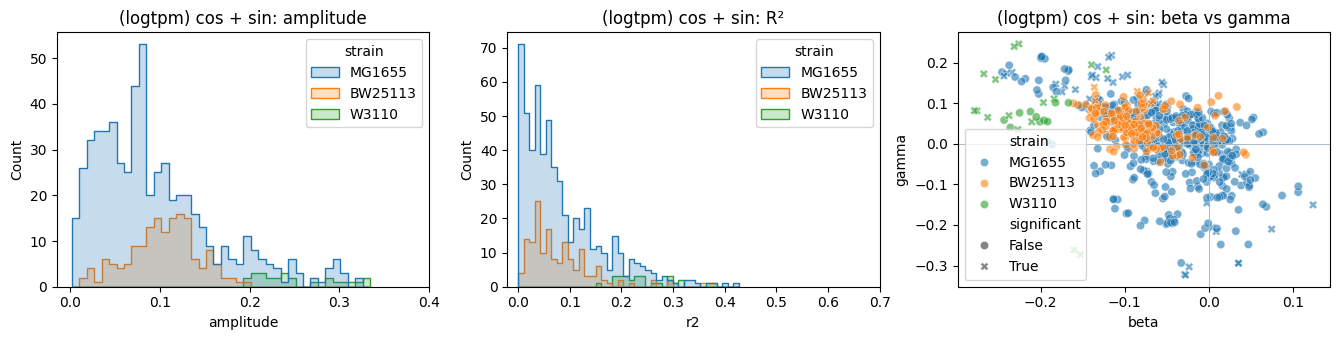

         n_significant  n_total  frac_significant
strain                                           
BW25113              7      160          0.043750
MG1655              41      582          0.070447
W3110               16       26          0.615385


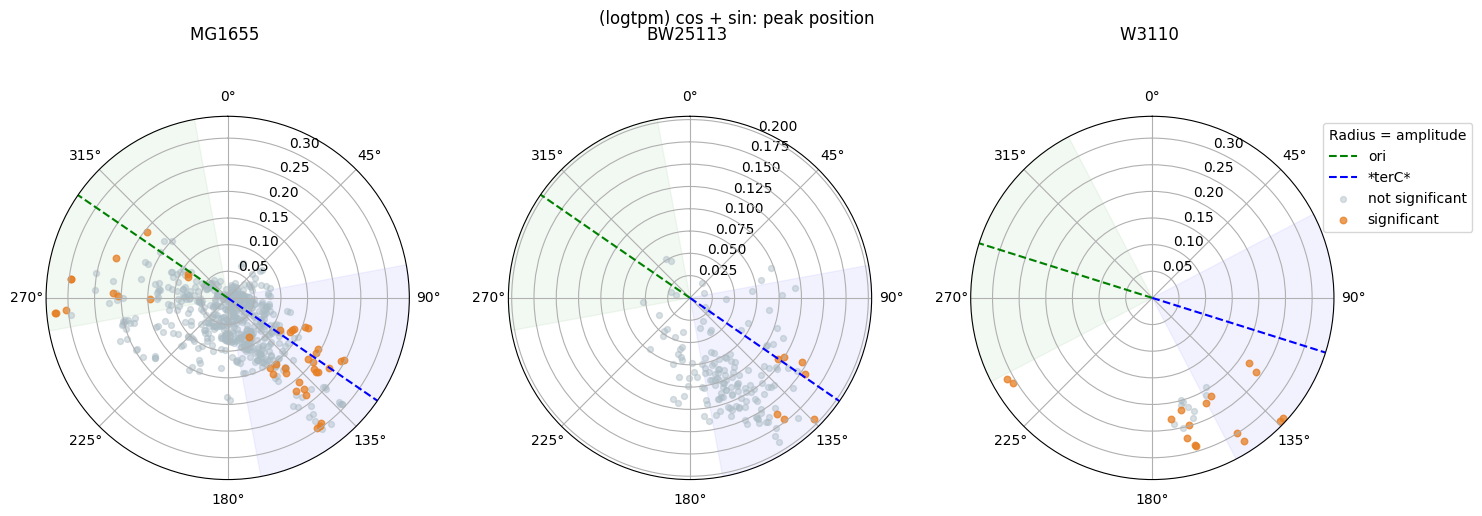

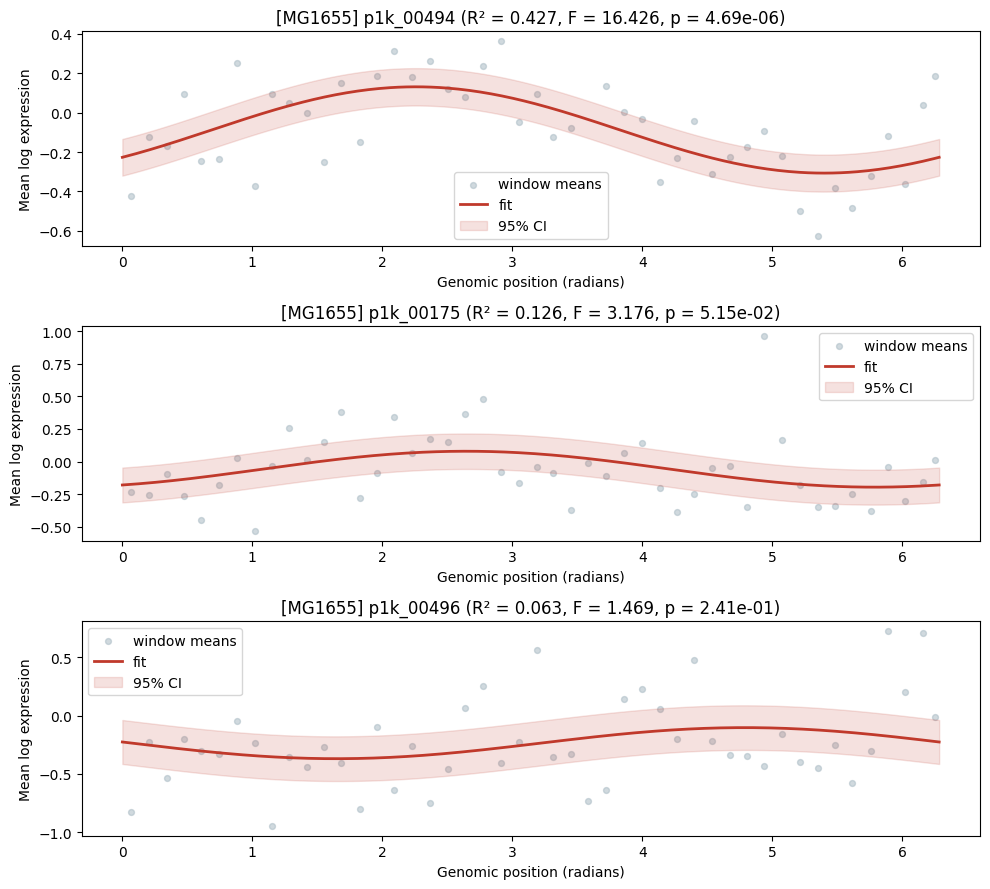

In [28]:
# Fit y = alpha + beta * cos(rad) + gamma * sin(rad)
combined_logtpm_both, models_logtpm_both = fit_all_strains(window_data_logtpm, terms = "both")
plot_distributions_comparison(combined_logtpm_both, terms = "both", title_prefix = "(logtpm) cos + sin")
plot_polar_comparison(combined_logtpm_both, title_prefix = "(logtpm) cos + sin")
plot_representative_fits(combined_logtpm_both, models_logtpm_both, window_data_logtpm, terms = "both")

### Cosine model, unaligned (`cos @ start`): $y(\theta) = \alpha + \beta \cos(\theta)$ 

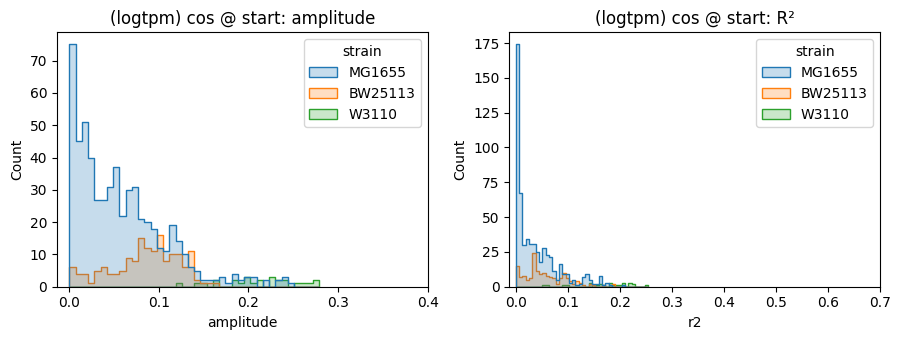

         n_significant  n_total  frac_significant
strain                                           
BW25113              0      160               0.0
MG1655               0      582               0.0
W3110                0       26               0.0


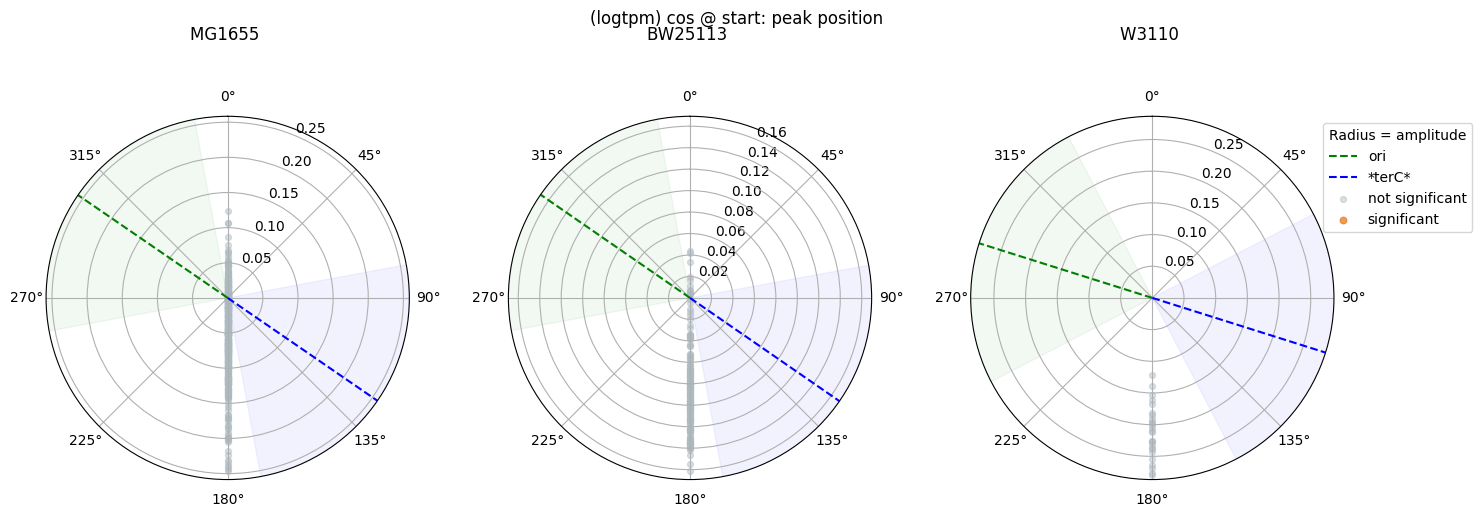

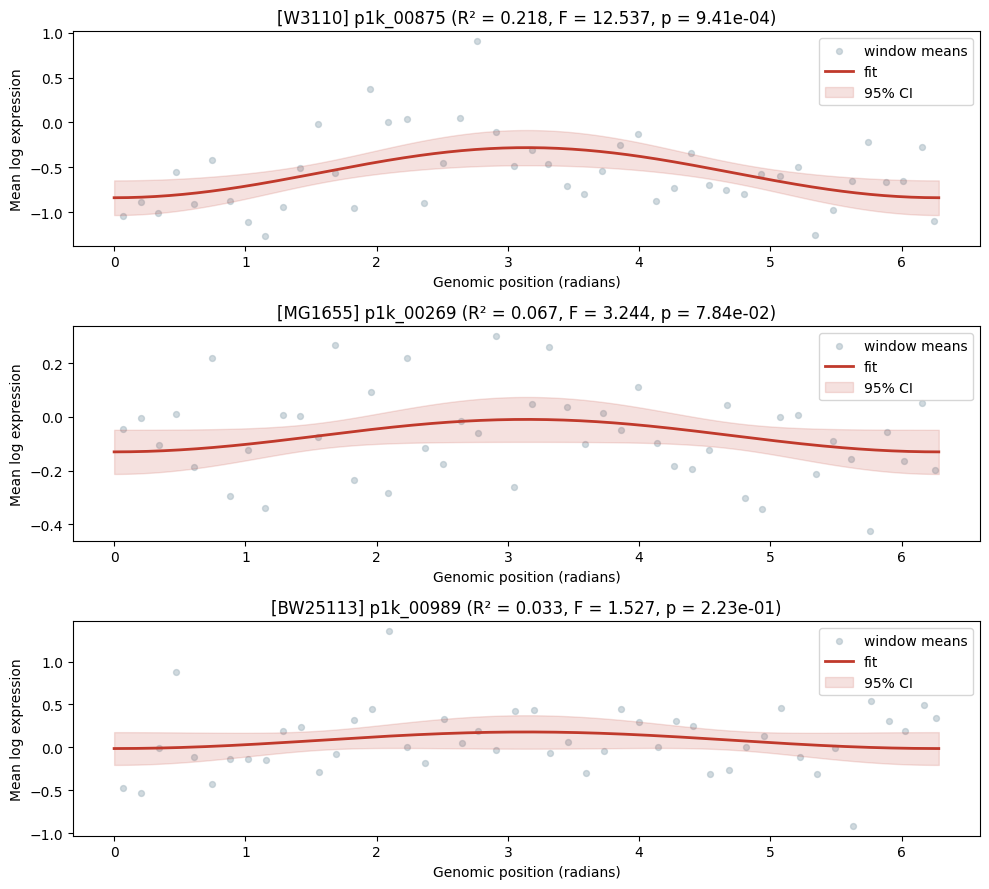

In [29]:
# Fit y = alpha + beta * cos(rad)
combined_logtpm_cos, models_logtpm_cos = fit_all_strains(window_data_logtpm, terms = "cos")
plot_distributions_comparison(combined_logtpm_cos, terms = "cos", title_prefix = "(logtpm) cos @ start")
plot_polar_comparison(combined_logtpm_cos, title_prefix = "(logtpm) cos @ start")
plot_representative_fits(combined_logtpm_cos, models_logtpm_cos, window_data_logtpm, terms = "cos")

### Sine model, unaligned (`sin @ start`): $y(\theta) = \alpha + \gamma \sin(\theta)$ 

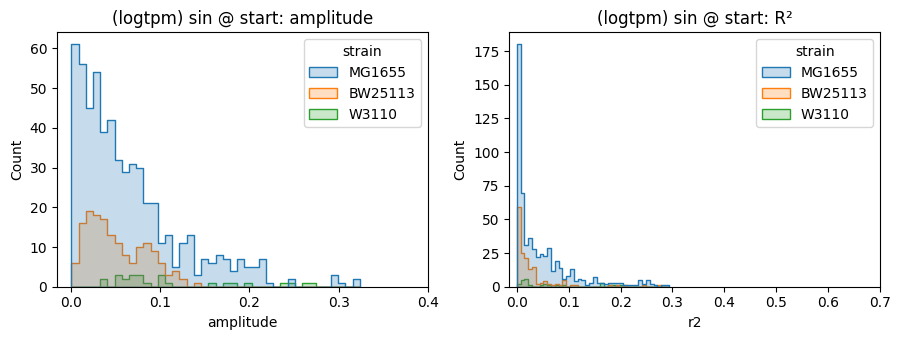

         n_significant  n_total  frac_significant
strain                                           
BW25113              3      160          0.018750
MG1655              26      582          0.044674
W3110                1       26          0.038462


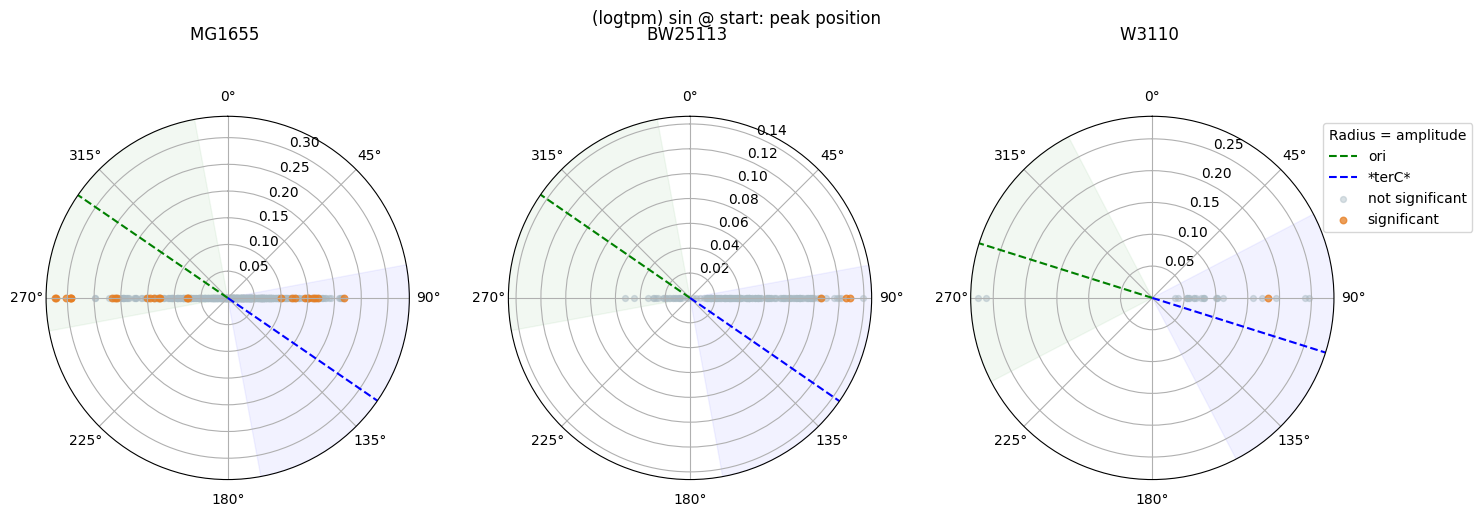

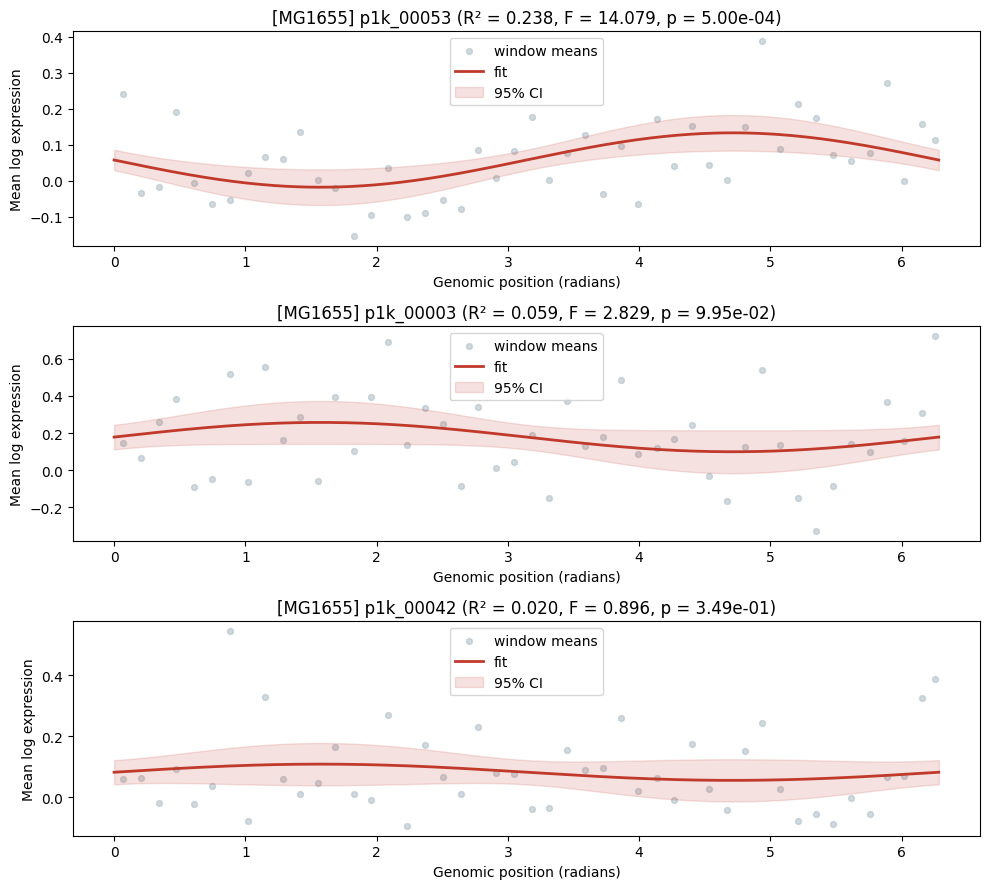

In [30]:
# Fit y = alpha + gamma * sin(rad)
combined_logtpm_sin, models_logtpm_sin = fit_all_strains(window_data_logtpm, terms = "sin")
plot_distributions_comparison(combined_logtpm_sin, terms = "sin", title_prefix = "(logtpm) sin @ start")
plot_polar_comparison(combined_logtpm_sin, title_prefix = "(logtpm) sin @ start")
plot_representative_fits(combined_logtpm_sin, models_logtpm_sin, window_data_logtpm, terms = "sin")

### Cosine model, *oriC*-aligned (`cos @ oriC`): $y(\theta) = \alpha + \beta \cos(\theta - \theta_{\text{ori}})$ 

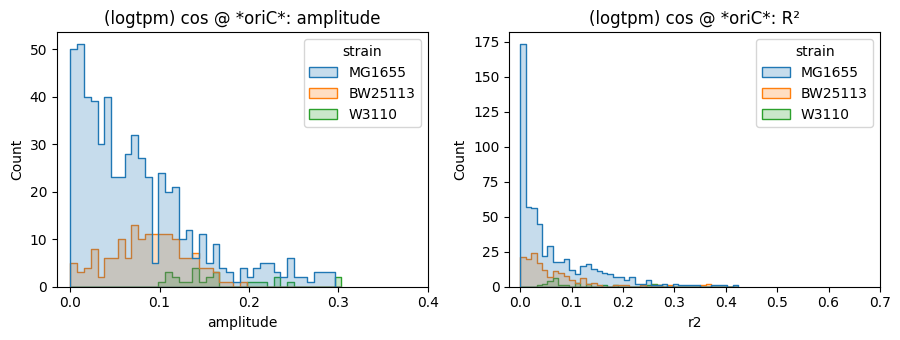

         n_significant  n_total  frac_significant
strain                                           
BW25113             10      160          0.062500
MG1655              70      582          0.120275
W3110                6       26          0.230769


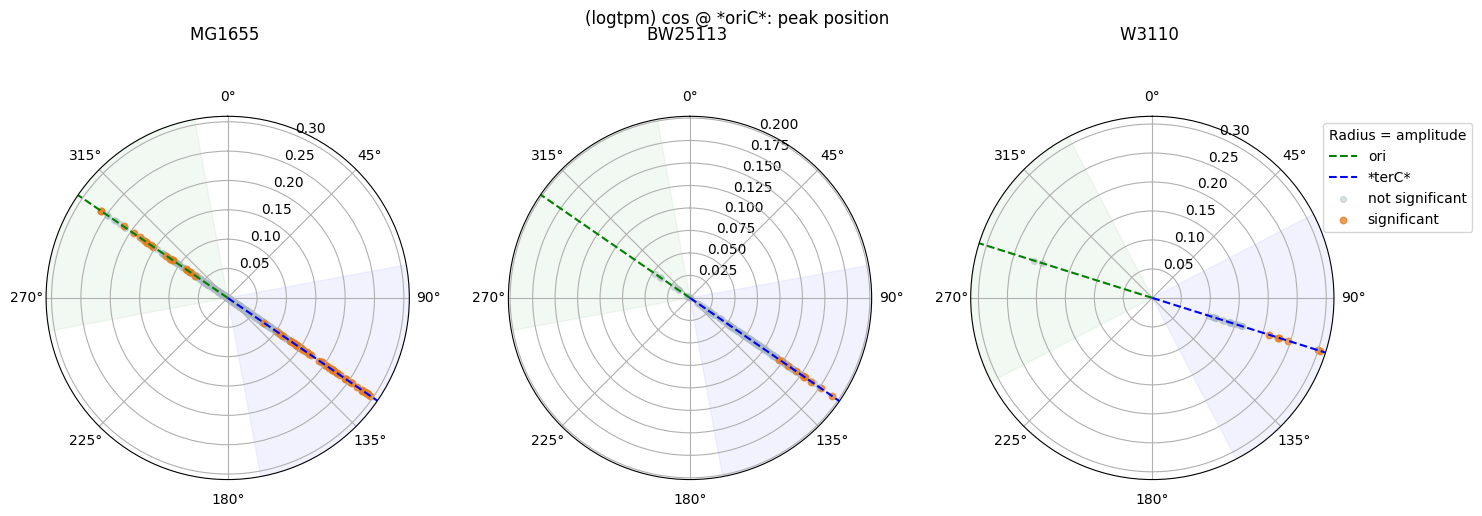

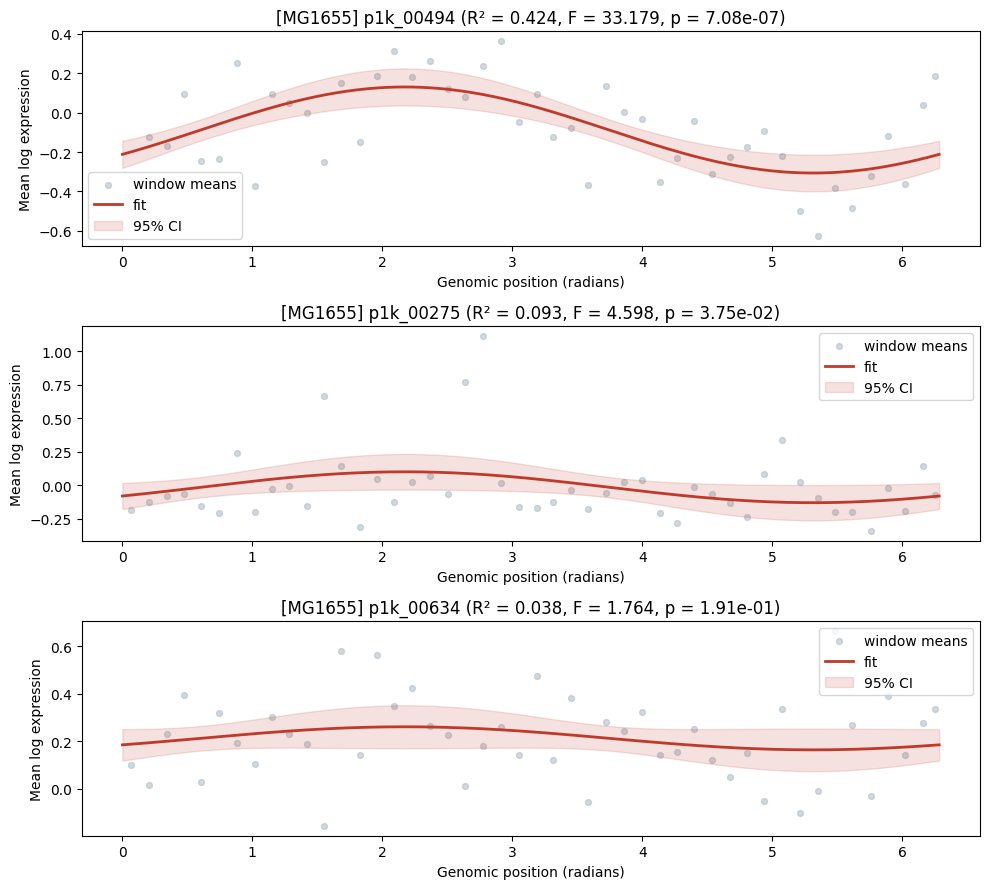

In [31]:
# Fit y = alpha + beta * cos(rad - ori_rad)
combined_logtpm_cos_ori, models_logtpm_cos_ori = fit_all_strains(window_data_logtpm, terms = "cos", phase_key = "ori")
plot_distributions_comparison(combined_logtpm_cos_ori, terms = "cos", title_prefix = "(logtpm) cos @ *oriC*")
plot_polar_comparison(combined_logtpm_cos_ori, title_prefix = "(logtpm) cos @ *oriC*")
plot_representative_fits(combined_logtpm_cos_ori, models_logtpm_cos_ori, window_data_logtpm, terms = "cos", phase_key = "ori")

### Sine model, *oriC*-aligned (`sin @ oriC`): $y(\theta) = \alpha + \gamma \sin(\theta - \theta_{\text{ori}})$ 

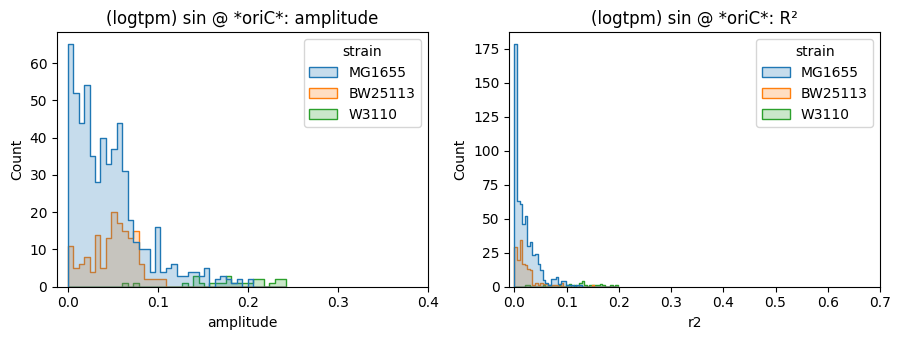

         n_significant  n_total  frac_significant
strain                                           
BW25113              0      160               0.0
MG1655               0      582               0.0
W3110                0       26               0.0


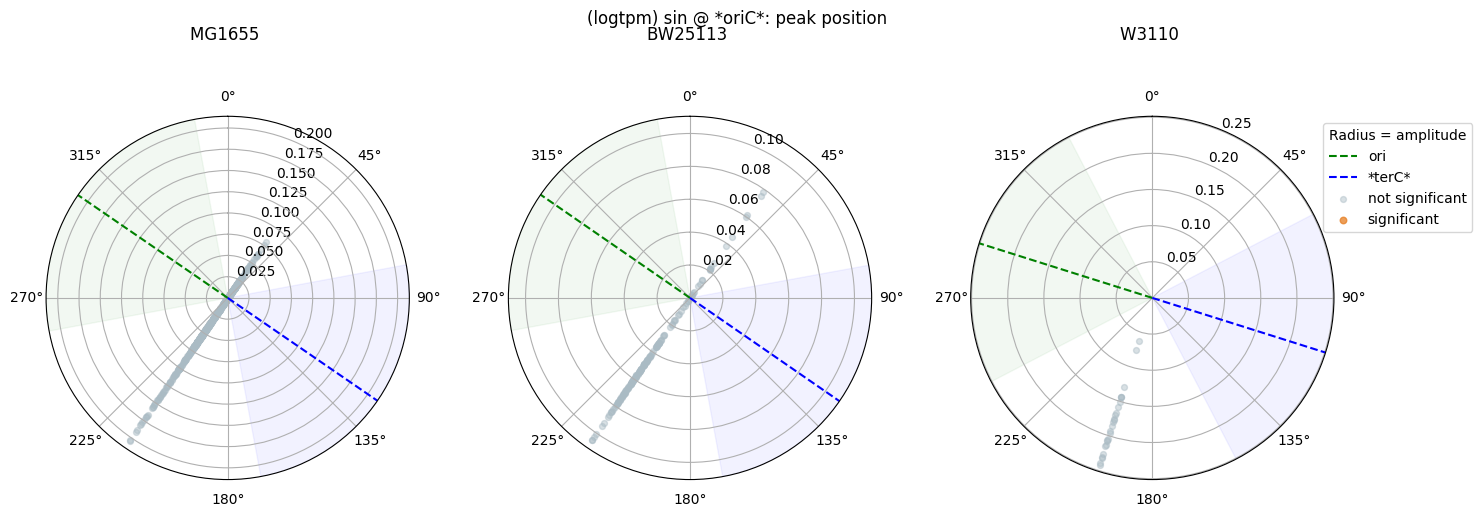

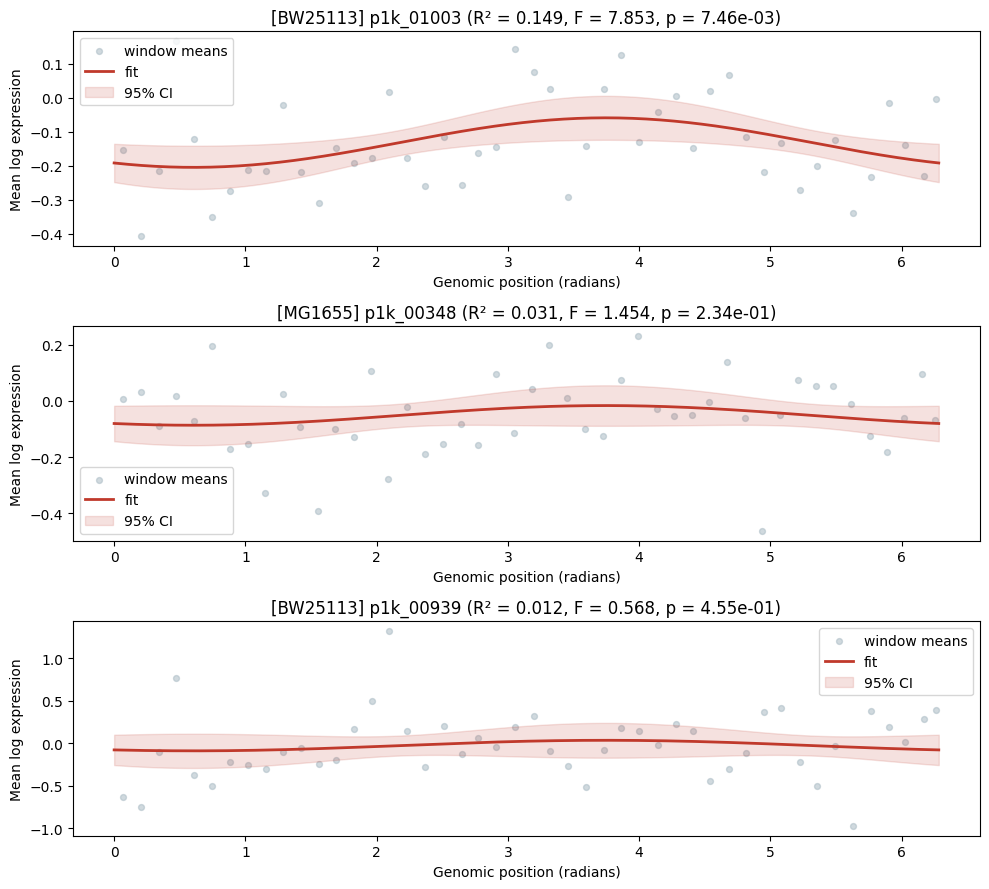

In [32]:
# Fit y = alpha + gamma * sin(rad - ori_rad)
combined_logtpm_sin_ori, models_logtpm_sin_ori = fit_all_strains(window_data_logtpm, terms = "sin", phase_key = "ori")
plot_distributions_comparison(combined_logtpm_sin_ori, terms = "sin", title_prefix = "(logtpm) sin @ *oriC*")
plot_polar_comparison(combined_logtpm_sin_ori, title_prefix = "(logtpm) sin @ *oriC*")
plot_representative_fits(combined_logtpm_sin_ori, models_logtpm_sin_ori, window_data_logtpm, terms = "sin", phase_key = "ori")

### **Observations**

* The full model detected a significant positional pattern in 32/582 MG1655 samples
* The unaligned cosine model detected no significant samples, while the unaligned sine model detected 26/582
* After aligning the model with *oriC*, the cosine model detected 65/582 significant MG1655 samples, the highest number among the tested models
* The *oriC*-aligned sine model detected no significant samples
* Overall the results show that the detected expression pattern depends strongly on the phase of the model and is mainly aligned with the *oriC*–terminus axis
* BW25113 shows the same general pattern, but with fewer significant samples

## 4.3. Harmonics fitting on scaled expression

The same harmonic models were repeated using filtered and scaled expression values. Scaling reduces differences in the usual expression level of individual genes and gives genes a more similar contribution to the genomic window averages. This analysis tests whether the chromosome-position signal becomes easier to detect after standardisation.

### Full model (`cos + sin`): $y(\theta) = \alpha + \beta \cos(\theta) + \gamma \sin(\theta)$ 

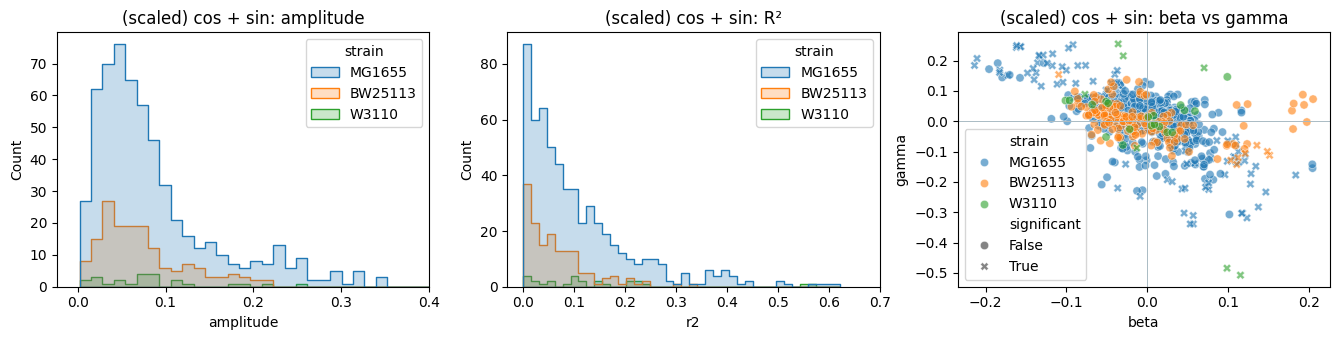

         n_significant  n_total  frac_significant
strain                                           
BW25113              8      160          0.050000
MG1655              85      582          0.146048
W3110                7       26          0.269231


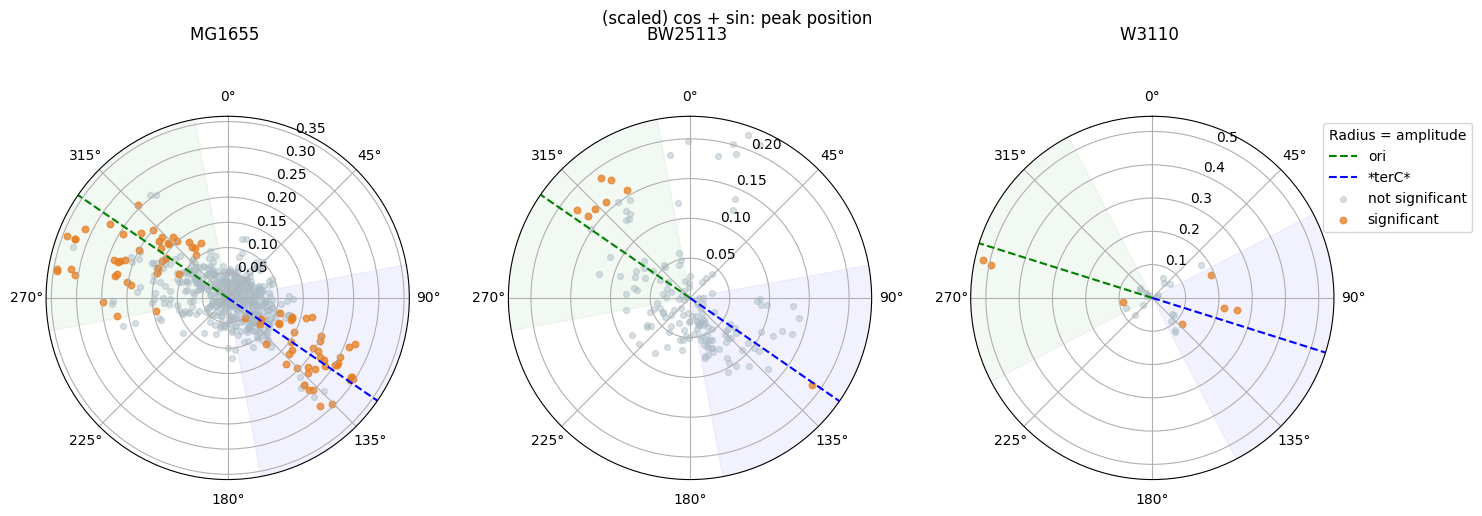

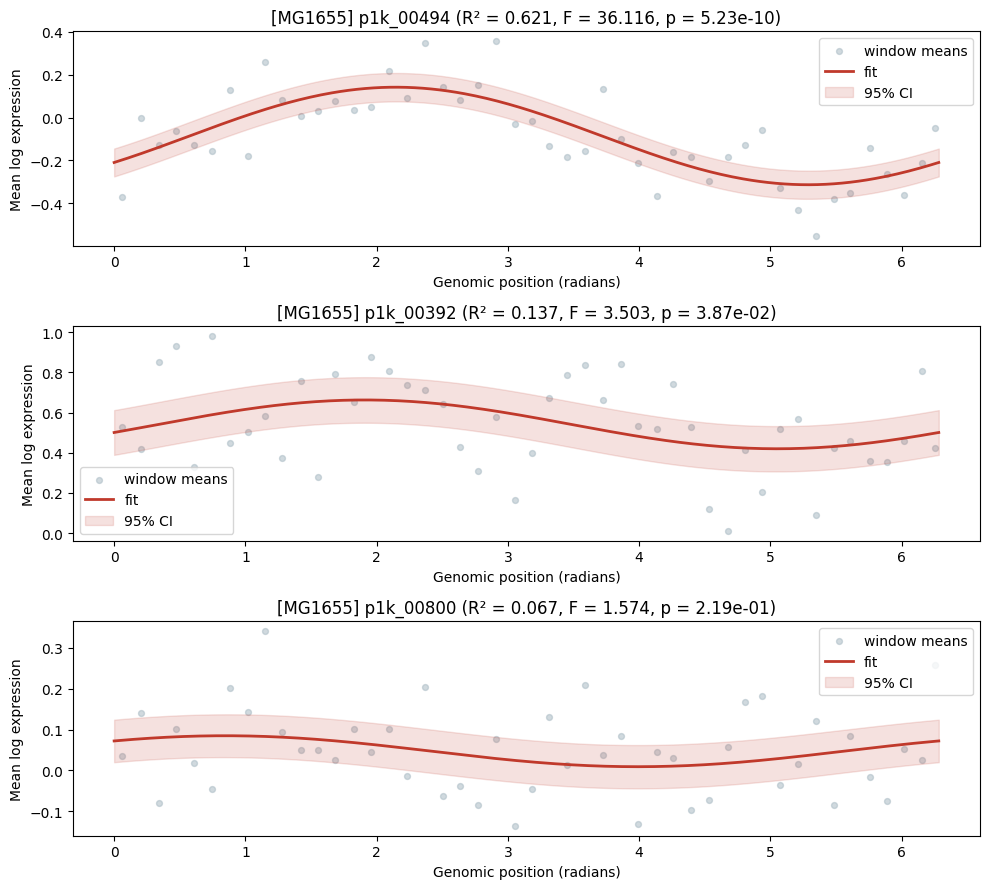

In [33]:
# Fit y = alpha + beta * cos(rad) + gamma * sin(rad)
combined_scaled_both, models_scaled_both = fit_all_strains(window_data_scaled, terms = "both")
plot_distributions_comparison(combined_scaled_both, terms = "both", title_prefix = "(scaled) cos + sin")
plot_polar_comparison(combined_scaled_both, title_prefix = "(scaled) cos + sin")
plot_representative_fits(combined_scaled_both, models_scaled_both, window_data_scaled, terms = "both")

### Cosine model, unaligned (`cos @ start`): $y(\theta) = \alpha + \beta \cos(\theta)$ 

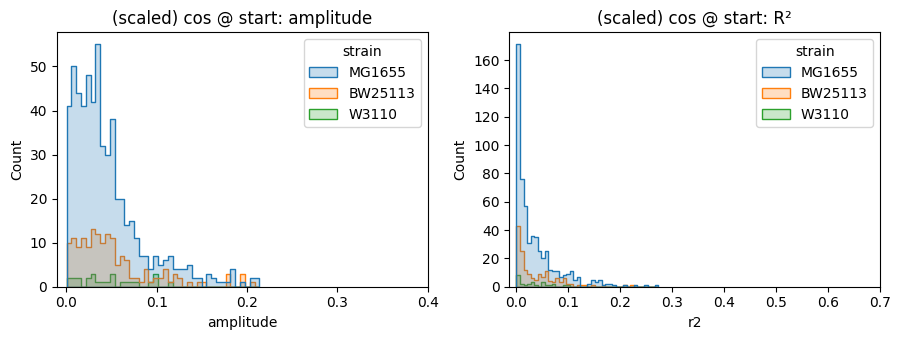

         n_significant  n_total  frac_significant
strain                                           
BW25113              0      160               0.0
MG1655               0      582               0.0
W3110                0       26               0.0


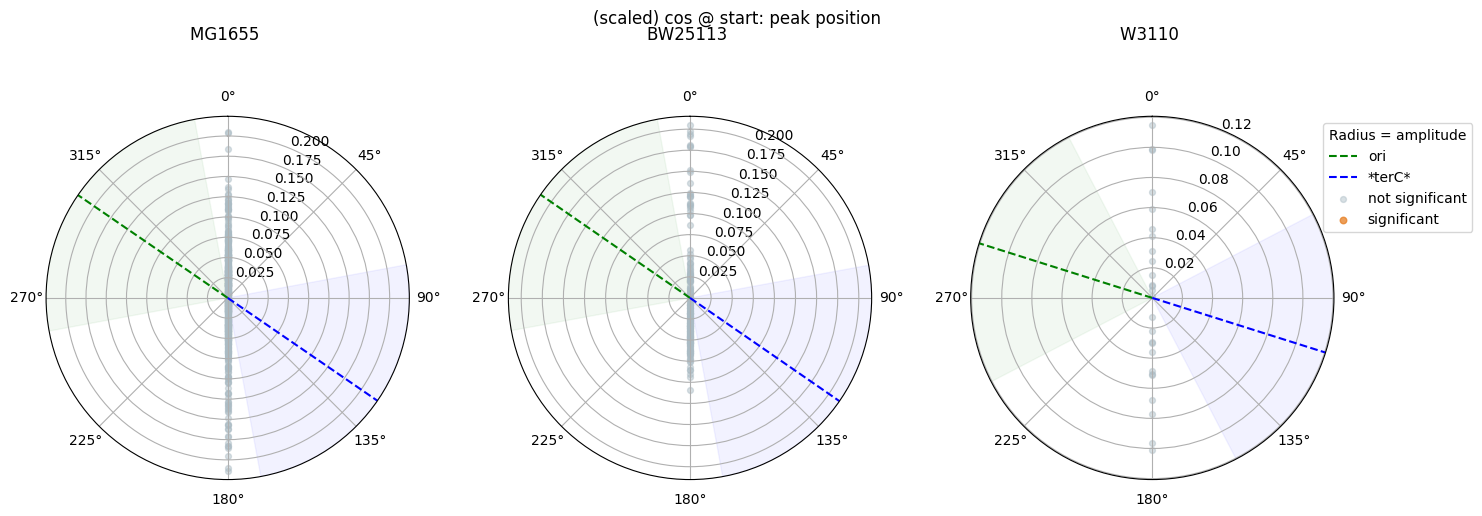

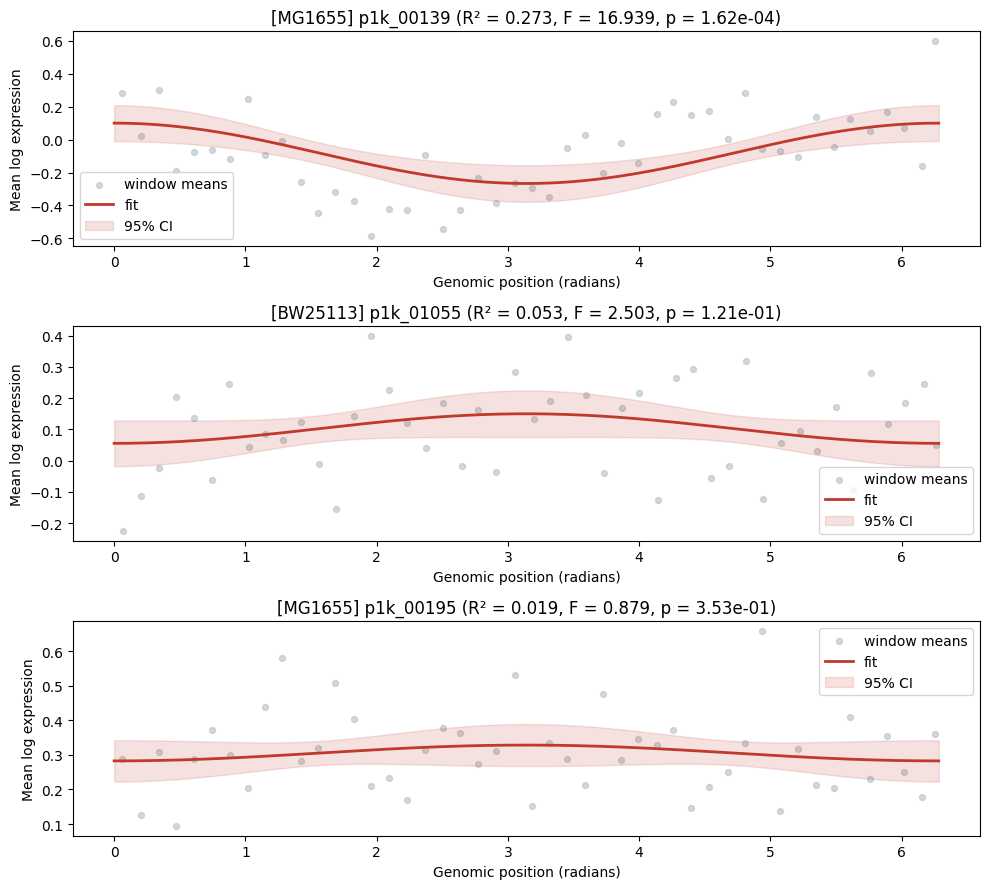

In [34]:
# Fit y = alpha + beta * cos(rad)
combined_scaled_cos, models_scaled_cos = fit_all_strains(window_data_scaled, terms = "cos")
plot_distributions_comparison(combined_scaled_cos, terms = "cos", title_prefix = "(scaled) cos @ start")
plot_polar_comparison(combined_scaled_cos, title_prefix = "(scaled) cos @ start")
plot_representative_fits(combined_scaled_cos, models_scaled_cos, window_data_scaled, terms = "cos")

### Sine model, unaligned (`sin @ start`): $y(\theta) = \alpha + \gamma \sin(\theta)$ 

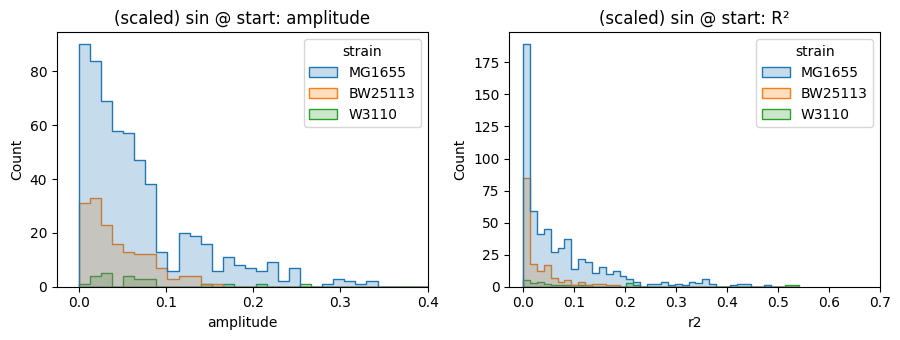

         n_significant  n_total  frac_significant
strain                                           
BW25113              2      160          0.012500
MG1655              74      582          0.127148
W3110                6       26          0.230769


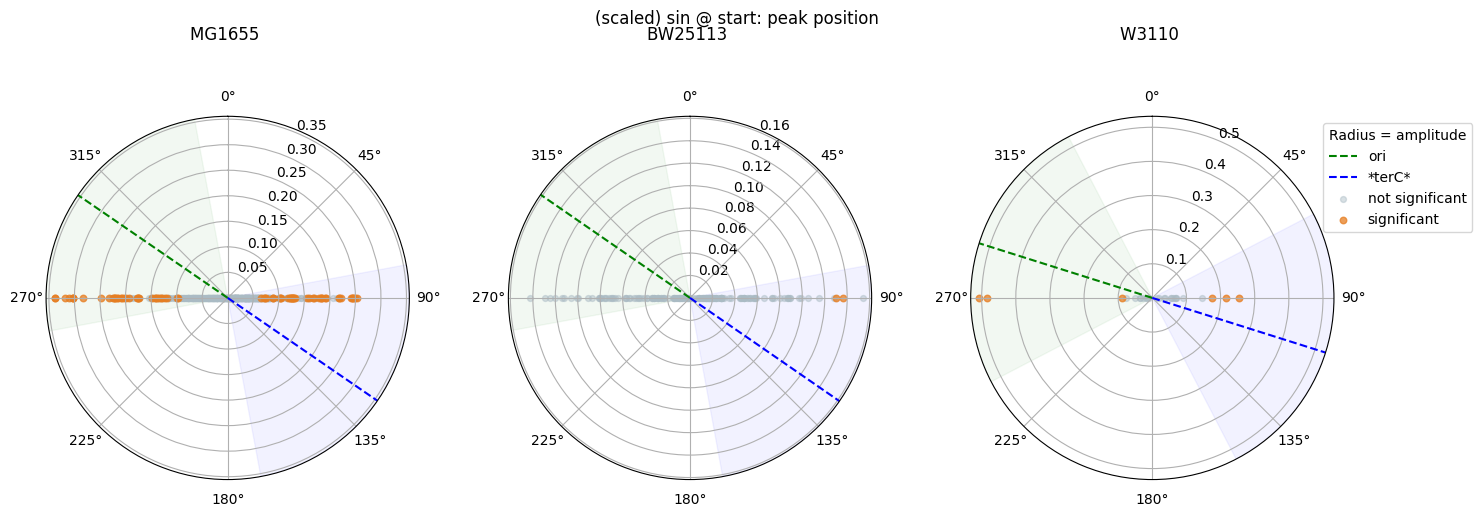

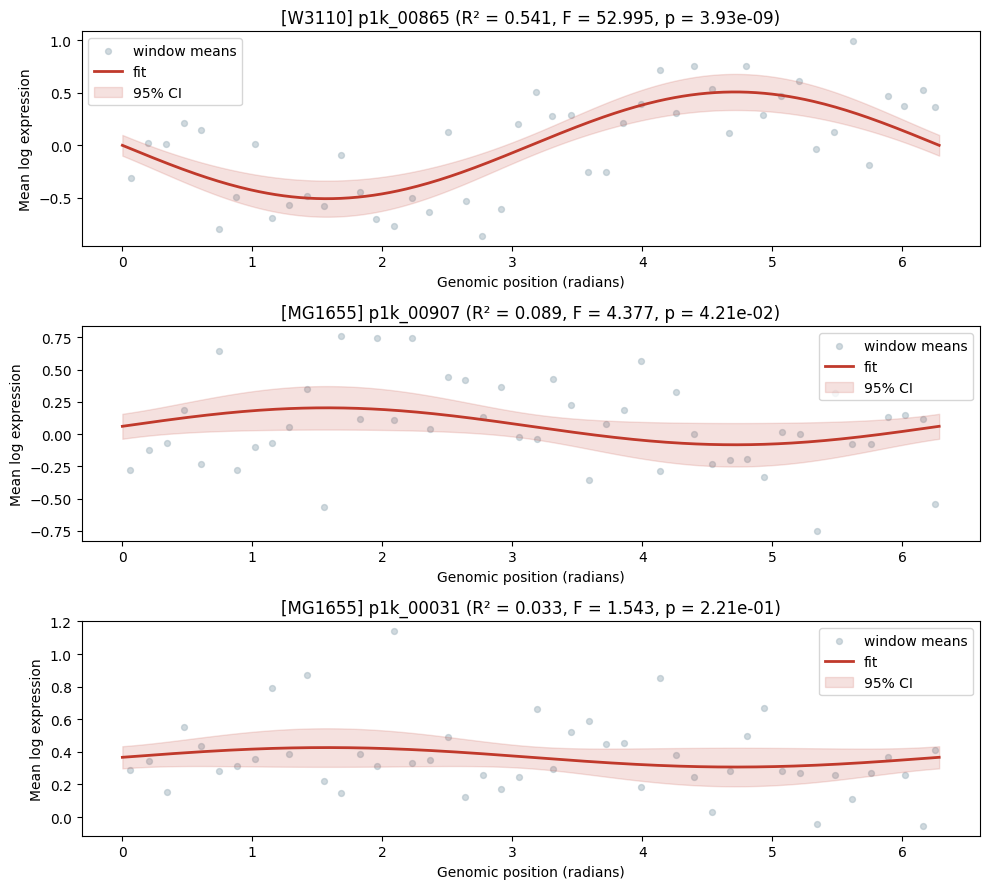

In [35]:
# Fit y = alpha + gamma * sin(rad)
combined_scaled_sin, models_scaled_sin = fit_all_strains(window_data_scaled, terms = "sin")
plot_distributions_comparison(combined_scaled_sin, terms = "sin", title_prefix = "(scaled) sin @ start")
plot_polar_comparison(combined_scaled_sin, title_prefix = "(scaled) sin @ start")
plot_representative_fits(combined_scaled_sin, models_scaled_sin, window_data_scaled, terms = "sin")

### Cosine model, *oriC*-aligned (`cos @ oriC`): $y(\theta) = \alpha + \beta \cos(\theta - \theta_{\text{ori}})$ 

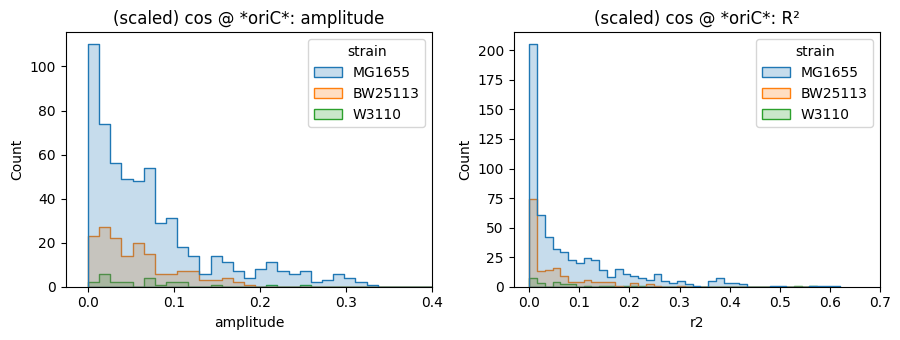

         n_significant  n_total  frac_significant
strain                                           
BW25113             16      160          0.100000
MG1655             123      582          0.211340
W3110                7       26          0.269231


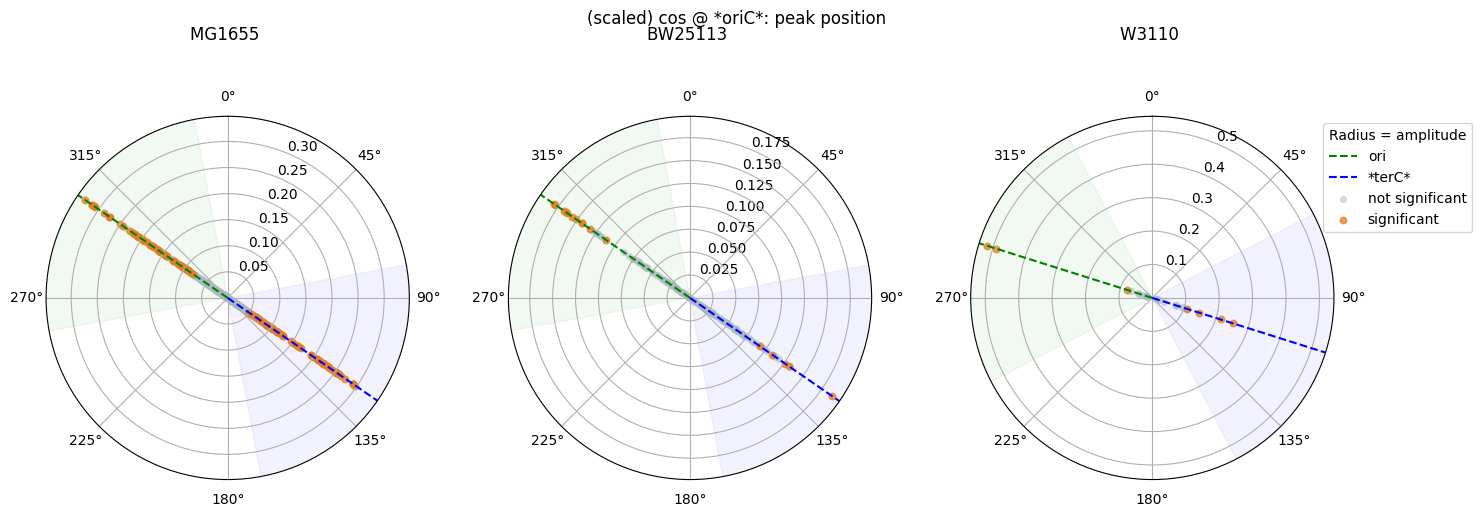

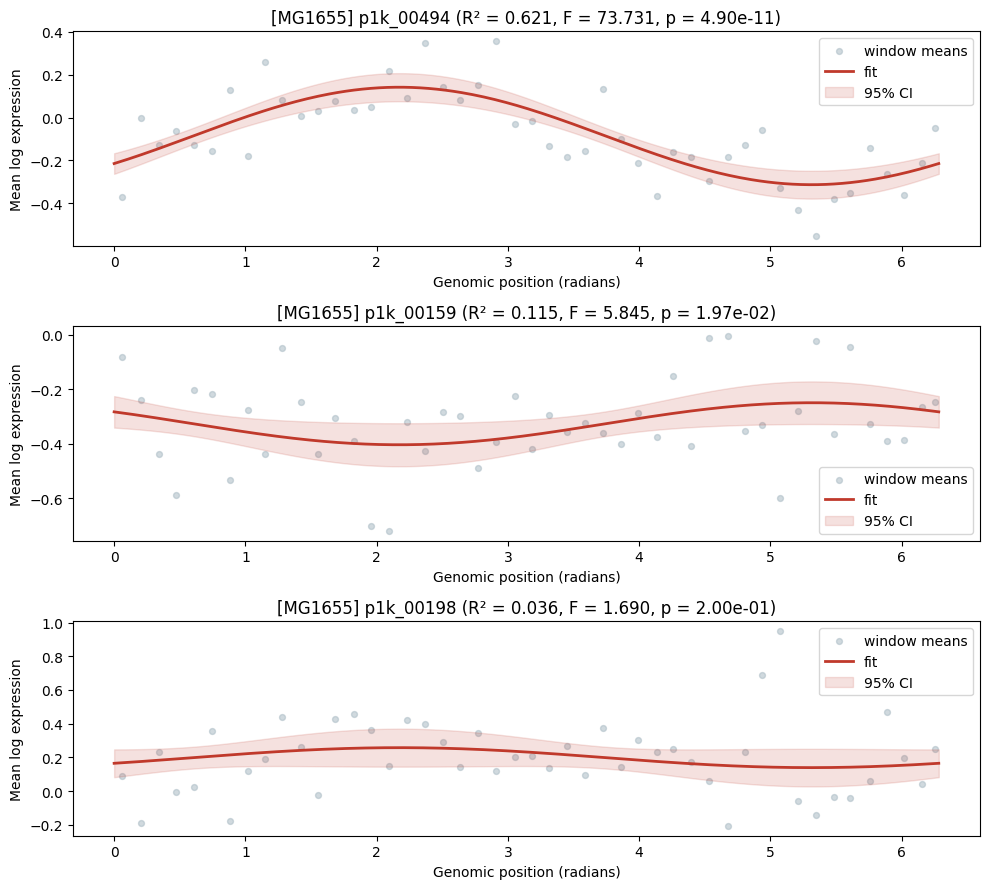

In [36]:
# Fit y = alpha + beta * cos(rad - ori_rad)
combined_scaled_cos_ori, models_scaled_cos_ori = fit_all_strains(window_data_scaled, terms = "cos", phase_key = "ori")
plot_distributions_comparison(combined_scaled_cos_ori, terms = "cos", title_prefix = "(scaled) cos @ *oriC*")
plot_polar_comparison(combined_scaled_cos_ori, title_prefix = "(scaled) cos @ *oriC*")
plot_representative_fits(combined_scaled_cos_ori, models_scaled_cos_ori, window_data_scaled, terms = "cos", phase_key = "ori")

### Sine model, *oriC*-aligned (`sin @ oriC`): $y(\theta) = \alpha + \gamma \sin(\theta - \theta_{\text{ori}})$ 

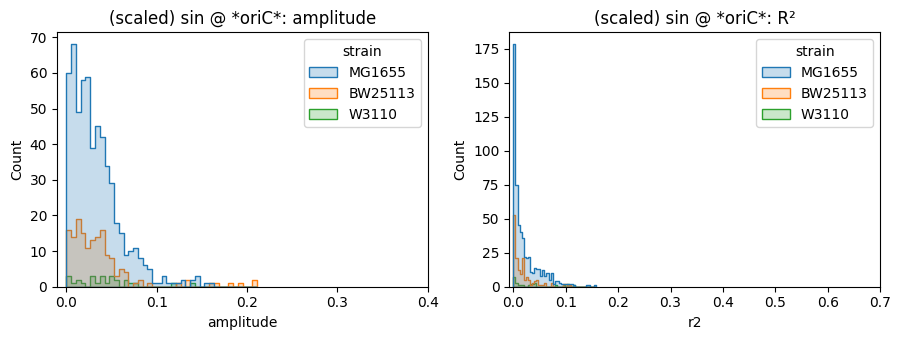

         n_significant  n_total  frac_significant
strain                                           
BW25113              0      160               0.0
MG1655               0      582               0.0
W3110                0       26               0.0


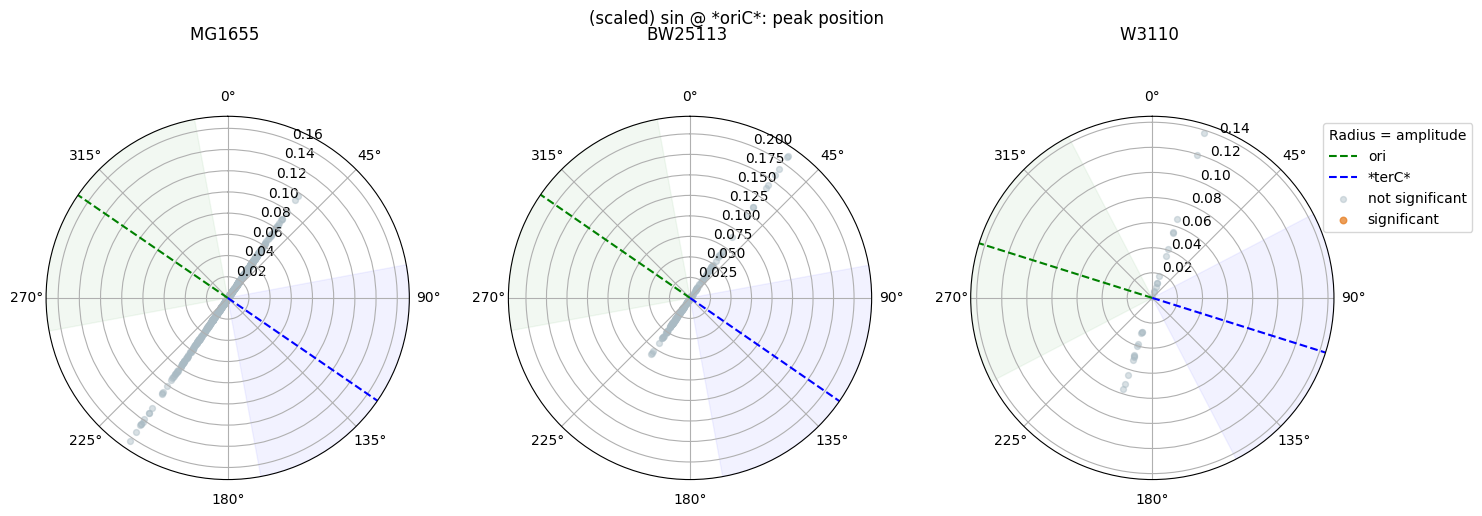

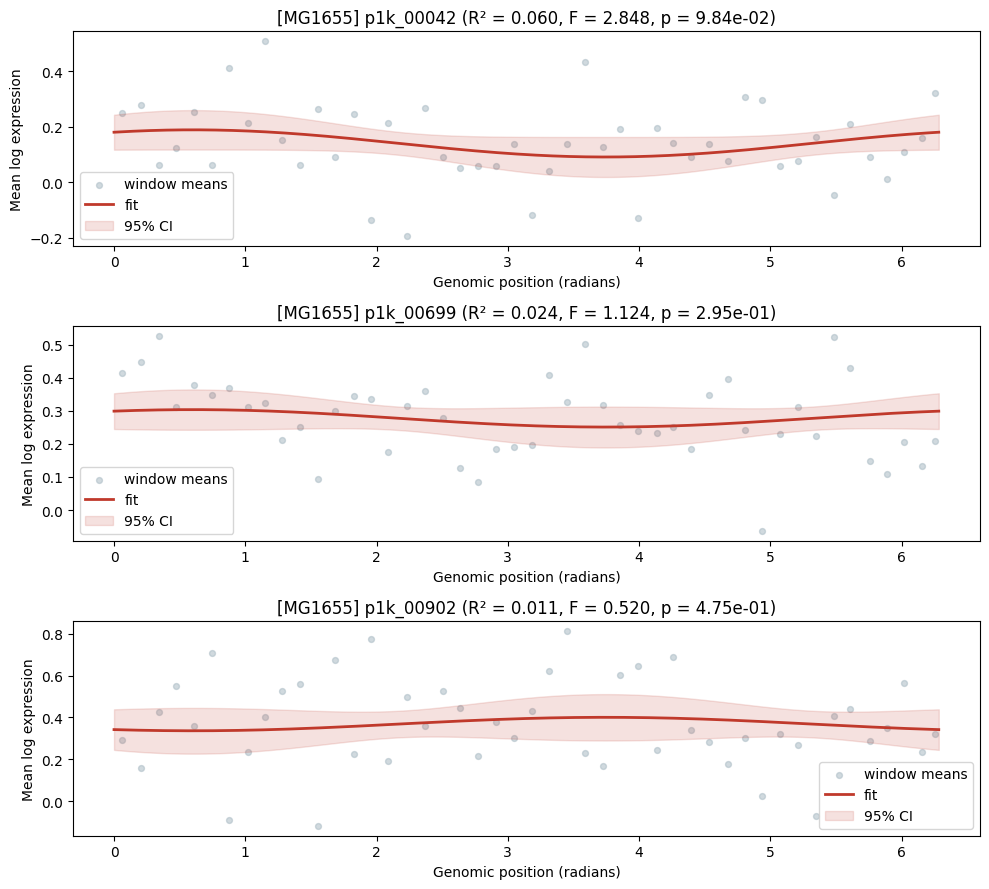

In [37]:
# Fit y = alpha + gamma * sin(rad - ori_rad)
combined_scaled_sin_ori, models_scaled_sin_ori = fit_all_strains(window_data_scaled, terms = "sin", phase_key = "ori")
plot_distributions_comparison(combined_scaled_sin_ori, terms = "sin", title_prefix = "(scaled) sin @ *oriC*")
plot_polar_comparison(combined_scaled_sin_ori, title_prefix = "(scaled) sin @ *oriC*")
plot_representative_fits(combined_scaled_sin_ori, models_scaled_sin_ori, window_data_scaled, terms = "sin", phase_key = "ori")

### **Observations**

* The full model detected 85/582 significant MG1655 samples

* The unaligned cosine model detected 0 significant samples, while the unaligned sine model detected 73/582

* After alignment with *oriC*, the cosine model detected 121/582 significant MG1655 samples, the highest number among the scaled models

* The *oriC*-aligned sine model detected 0 significant samples

* Most samples still have low R², showing that chromosome position explains only part of the variation in gene expression

* Overall the scaled analysis shows the same main pattern as the logTPM analysis: the signal is strongest when the cosine model is aligned with the oriC–terminus axis

* Interestingly, in the `sin @ start` case quite some significant samples appear in strain W3110 (23% of the total), compared to lower relative amounts in the other two. One possible explanation could be the fact that the origin of replication of that strain, out of all the three, lies the closest to the 90°/270° axis.

* Compared with the logTPM analysis, scaling increased the number of significant samples in the full and *oriC*-aligned cosine models. This suggests that differences in baseline expression between genes may hide part of the chromosome-wide signal, while scaling makes the shared positional pattern easier to detect.

* Fitting of `cos @ oriC` having more significant samples compared to `cos + sin` appears counterintuitive, due to the fact of that model having less flexibility. Indeed, `cos + sin` models have generally a higher R² score compared to the former ones. The fact that `cos @ oriC` models, even though they are less capable of explaining gene expression variance, have more significance is due to the lower amount of degrees of freedom of the model itself.

# 5. Growth rate from harmonics fitting

During this section, we analyse the relationship between the results of harmonics model fitting and samples growth rate. Many samples are unannotated for growth rate, and we decided to only focus on those with a valid measurement. As such, only samples from strains MG1655 and BW25113 will be considered.

**Note:** even though growth rate prediction of unannotated samples is mentioned as a possible task in the project assignment, we chose not to include due to the absence of a proper way to actually determine the accuracy of the results. For sections in which we do perform growth rate regression, we split the annotated samples dataset in order to have a test set to measure the obtained predictive performance.

## 5.1. Model fitting vs growth rate visualization

In these following analyses, we inspect the relationship between fitted spatial parameters and sample growth rate distributions. We select the two most conceptually meaningful harmonics model classes (`cos + sin` and `cos @ oriC`), both fitted on logTPM and scaled expression data, to verify whether there is an observable relationship between fitted parameters (amplitude and peak position) and growth rate.

We first define a function that plots fitted amplitude and peak position for each sample in polar coordinates, colored by growth rate.

In [38]:
def plot_polar_growth_rate(combined, samples_str, title_prefix):

    strains = list(samples_str.keys() & ref_anns.keys())
    fig, axes = plt.subplots(1, len(strains), figsize = (5 * len(strains), 5), subplot_kw = {"projection": "polar"})
    axes = np.atleast_1d(axes)

    # Share color scale across all strains
    all_gr = []
    for strain in strains:
        gr = samples_str[strain]["Growth Rate (1/hr)"]
        all_gr.append(gr)
    vmin = pd.concat(all_gr).min()
    vmax = pd.concat(all_gr).max()

    sc = None
    for ax, strain in zip(axes, strains):

        ref = ref_builds[strain]
        ax.axvline(ref["ori_rad"], color = "green", ls = "--", lw = 1.5, label = "ori")
        ax.axvline(ref["ter_rad"], color = "blue",  ls = "--", lw = 1.5, label = "*terC*")

        # Subset strain and annotated samples
        sub = combined[combined["strain"] == strain].join(samples_str[strain]["Growth Rate (1/hr)"], how = "inner")

        # Plot fitting results colored by growth rate
        sc = ax.scatter(sub["peak_position_rad"], sub["amplitude"],
                        c = sub["Growth Rate (1/hr)"], cmap = "plasma",
                        vmin = vmin, vmax = vmax, s = 25, alpha = 0.8)

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_title(f'{strain}\n\n')

    fig.colorbar(sc, ax = axes, label = "Growth rate (1/hr)", pad = 0.1, shrink = 0.7)
    fig.suptitle(f"{title_prefix}: growth rate")
    plt.show()

### LogTPM expression data, `cos + sin`:

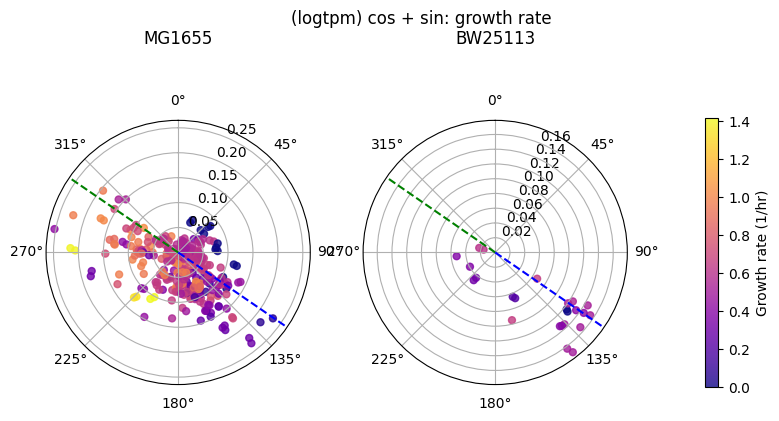

In [39]:
plot_polar_growth_rate(combined_logtpm_both, samples_str_ann, title_prefix = "(logtpm) cos + sin")

### LogTPM expression data, `cos @ oriC`:

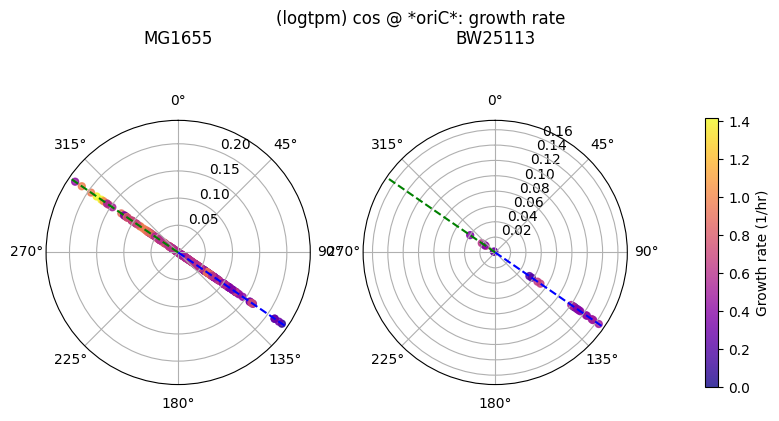

In [40]:
plot_polar_growth_rate(combined_logtpm_cos_ori, samples_str_ann, title_prefix = "(logtpm) cos @ *oriC*")

### Scaled expression data, `cos + sin`:

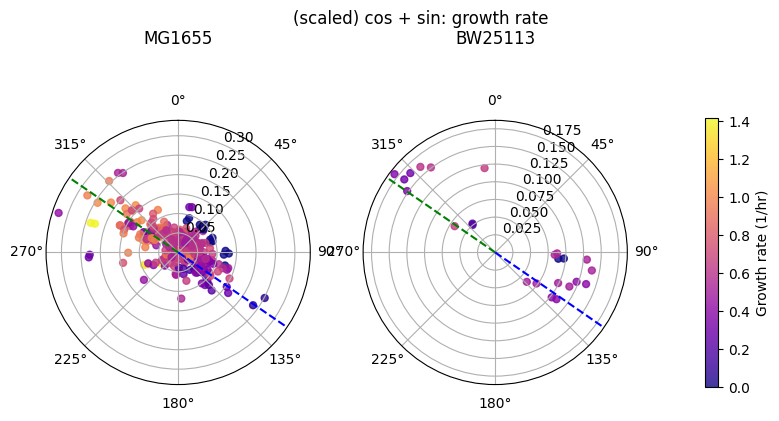

In [41]:
plot_polar_growth_rate(combined_scaled_both, samples_str_ann, title_prefix = "(scaled) cos + sin")

### Scaled expression data, `cos @ oriC`:

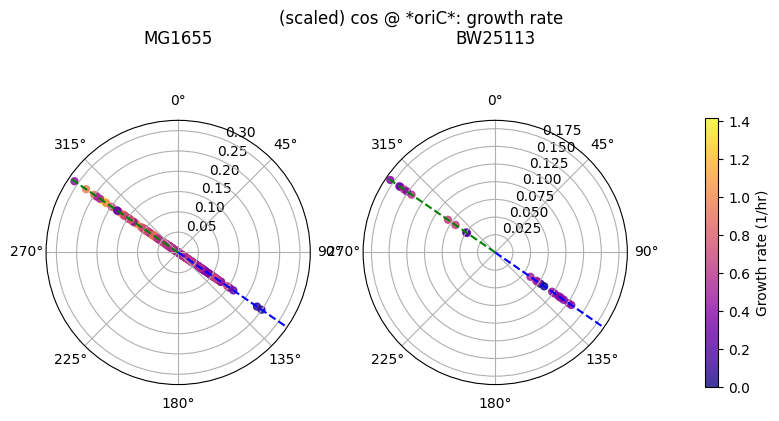

In [42]:
plot_polar_growth_rate(combined_scaled_cos_ori, samples_str_ann, title_prefix = "(scaled) cos @ *oriC*")

### **Conclusions**

* Across both logTPM and scaled expression data, just by visual inspection it is possible to notice a gradient in growth rate depending on both fitted amplitude and peak position. In particular, for samples with high amplitude,those with peak position located around *oriC* tend to have higher growth rate than that of the ones with peak position located around *terC*.

* LogTPM and scaled expression data results, although different in samples fitting significance, show similar visual pattern; a quantitative measurement of correlation with growth rate will be performer in the following analyses to test their predictive performances.

## 5.2. Helmstetter-Cooper validation

In this section, we compare our results with those predicted by the work of Helmstetter and Cooper, in particular only considering the results obtained from fitting on $log_2(TPM)$ expression data.

The fitted coefficient β from our *oriC*-aligned cosine model (`cos @ oriC`) tells us the total distance from the absolute top to the absolute bottom: ($|2{\beta}|$). Because the data are in log scale, the height of the wave represents the log-ratio of gene copies near the origin compared to the terminus.

The Helmstetter-Cooper framework implies that fast-growing bacteria start new rounds of DNA replication before the previous one finishes. This is the idea behind the dosage gradient across the chromosome, and it scales steeper at higher growth rates. The simple rule explaining this concept:

$$Wave Height = (Replication Time (C) / ln(2)) * Growth Rate (μ)$$

We now plot the fitted wave heights against real growth rates and compare our observations with the theoretical predictions.

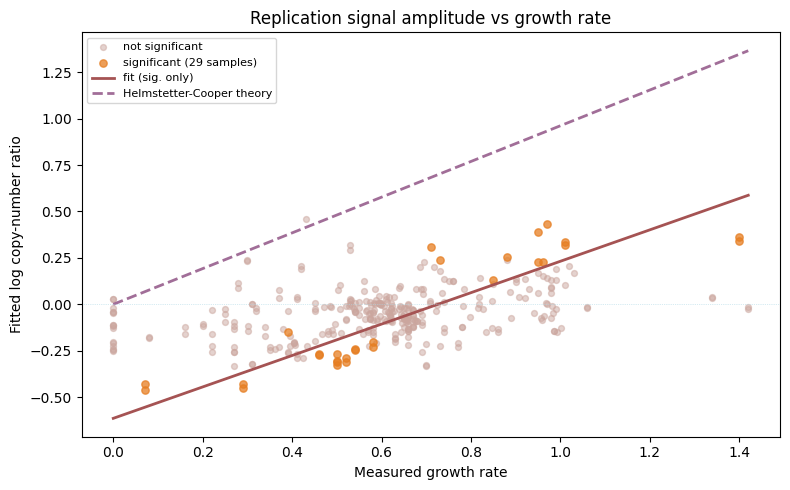

Fitted slope = 0.846 h  (Helmstetter-Cooper theory expects C ≈ 0.96 h)
R² = 0.802, F(1, 27) = 109.21, p = 5.47e-11, n = 29


In [43]:
rows = []
for strain in ref_builds.keys():
    sub = combined_logtpm_cos_ori[combined_logtpm_cos_ori["strain"] == strain].copy()
    gr  = samples_str[strain]["Growth Rate (1/hr)"]
    sub = sub.join(gr, how = "inner")
    sub = sub.dropna(subset = ["Growth Rate (1/hr)"])
    rows.append(sub)

beta_gr = pd.concat(rows)

# 2 * beta is the log copy-number ratio
beta_gr["log_ratio"] = 2 * beta_gr["beta"]

sig    = beta_gr[ beta_gr["significant"]]
nonsig = beta_gr[~beta_gr["significant"]]

# Linear regression with only the significant samples 
slope, intercept, r_val, p_val, _ = linregress(
    sig["Growth Rate (1/hr)"], sig["log_ratio"])

# Compute F-statistic
n = len(sig)
r2 = r_val**2
f_stat = r2 * (n - 2) / (1 - r2)

# Theoretical Helmstetter-Cooper slope in logscale as dataset: (C/ln2) * growth_rate
C_hours  = 40 / 60
slope_theoretical = C_hours/np.log(2)
gr_range = np.linspace(0, beta_gr["Growth Rate (1/hr)"].max(), 200)

fig, ax = plt.subplots(figsize = (8, 5))

ax.scatter(nonsig["Growth Rate (1/hr)"], nonsig["log_ratio"],
           color = "#cba69e", alpha = 0.5, s = 18,
           label = "not significant")
ax.scatter(sig["Growth Rate (1/hr)"], sig["log_ratio"],
           color = "#E67E22", alpha = 0.75, s = 28,
           label = f"significant ({len(sig)} samples)")

# Regression line (significant samples)
ax.plot(gr_range, slope * gr_range + intercept,
        color = "#a55353", lw = 2,
        label = f"fit (sig. only)")

# Helmstetter-Cooper slope
ax.plot(gr_range, slope_theoretical * gr_range,
        color = "#a16e98", lw = 2, ls = "--",
        label = f"Helmstetter-Cooper theory")

ax.axhline(0, color = "lightblue", lw = 0.5, ls = ":")
ax.set_xlabel("Measured growth rate")
ax.set_ylabel("Fitted log copy-number ratio")
ax.set_title("Replication signal amplitude vs growth rate")
ax.legend(fontsize = 8)
plt.tight_layout()
plt.show()

print(f"Fitted slope = {slope:.3f} h  (Helmstetter-Cooper theory expects C \u2248 {slope_theoretical:.2f} h)")
print(f"R² = {r2:.3f}, F({1}, {n - 2}) = {f_stat:.2f}, p = {p_val:.2e}, n = {n}")

### **Observations:**

* The fitted slope is 0.846 hours, which is close but a bit lower than Helmstetter-Cooper theory expects of 0.96 hours. For the significant samples we can observe a clear linear relationship which may suggest that the expression gradient is actually driven by the copy-number gradient. 

* Some samples show a negative β value; we hypothesize such occurrence may be due to slow-growing or stressed bacterial cultures.

* As seen in the plot above, there is a slight mismatch between the expected Helmstetter-Cooper slope and the predicted slope. In practice, RNA expression rarely reflects the physical DNA copy-number perfectly. This concept is called transcriptional buffering, where we may observe: 
    * Bacterial cultures use local transcription factors plus global feedback loops to buffer gene dosage effects and maintain homeostasis. The expression may be dampened relative to the raw copy number.
    * The decay of mRNA happens at different rates which in turn smooths out the sharp gradients that can be caused by the replication forks. 
    * It can also be due to averaging of gene expression in bulk RNA-seq.

## 5.3. Model fitting vs growth rate correlation

We now verify whether there is a measurable correlation between fitted parameters and growth rate. We start by defining some utility functions that will help with the analysis. Rather than testing amplitude and peak position separately, we project them for each sample into cartesian coordinates relative to *oriC* and fit growth rate as a linear function of both components. This lets us capture both the strength and the direction of the gradient in a single test, being also able to compare full and single-component results.

We start by defining a function to integrate growth rate information with each sample's harmonic fit results.

In [44]:
def prepare_growth_rate_data(combined, samples_str, ref_builds):
    rows = []
    for strain in ref_builds.keys():
        sub = combined[combined["strain"] == strain].copy()
        gr = samples_str[strain]["Growth Rate (1/hr)"]

        sub = sub.join(gr, how = "inner")
        sub = sub.dropna(subset = ["Growth Rate (1/hr)"])

        ori_rad = ref_builds[strain]["ori_rad"]
        diff = np.abs(sub["peak_position_rad"] - ori_rad)
        sub["dist_from_ori"] = np.minimum(diff, 2 * np.pi - diff)

        rows.append(sub)

    return pd.concat(rows)

We convert each sample's fitted amplitude and peak position into cartesian components relative to their strain of reference's *oriC*: `x_comp`, aligned with the *oriC*/*terC* axis, and `y_comp`, perpendicular to it. For the `cos @ oriC` and `sin @ oriC` models, peak position can only take one of two fixed values relative to *oriC*, so `y_comp` (or `x_comp`, for the sine case) will be 0 for every sample.

In [45]:
def add_polar_components(data, ref_builds):
    data = data.copy()
    x_comp = np.zeros(len(data))
    y_comp = np.zeros(len(data))

    for strain, ref in ref_builds.items():
        mask = (data["strain"] == strain).values
        ori_rad = ref["ori_rad"]
        rel_phase = data.loc[mask, "peak_position_rad"].values - ori_rad
        A = data.loc[mask, "amplitude"].values
        x_comp[mask] = A * np.cos(rel_phase)
        y_comp[mask] = A * np.sin(rel_phase)

    data["x_comp"] = x_comp
    data["y_comp"] = y_comp
    return data

We then prepare a function for fitting growth rate as a linear function of `x_comp` and `y_comp` via OLS and reporting R², F-statistic and p-value for each harmonic model variant tested.

In [46]:
def test_joint_amplitude_phase(data, label):
    X = sm.add_constant(data[["x_comp", "y_comp"]])
    y = data["Growth Rate (1/hr)"]
    model = sm.OLS(y, X).fit()

    return {
        "model": label,
        "n": len(data),
        "R2": model.rsquared,
        "F": model.fvalue,
        "p_value": model.f_pvalue,
    }

We now test the correlation between harmonics fitting results on logTPM data and growth rate, using the same `x_comp` and `y_comp` decomposition for all five harmonic model variants.

In [47]:
model_logtpm_variants = {
    "cos + sin":   combined_logtpm_both,
    "cos @ start": combined_logtpm_cos,
    "sin @ start": combined_logtpm_sin,
    "cos @ *oriC*":  combined_logtpm_cos_ori,
    "sin @ *oriC*":  combined_logtpm_sin_ori,
}

joint_results = []
for label, combined in model_logtpm_variants.items():
    data = prepare_growth_rate_data(combined, samples_str, ref_builds)
    data = add_polar_components(data, ref_builds)
    joint_results.append(test_joint_amplitude_phase(data, label))

joint_results_logtpm_df = pd.DataFrame(joint_results)
joint_results_logtpm_df["p_adj"] = multipletests(joint_results_logtpm_df["p_value"], method = "fdr_bh")[1]
print(joint_results_logtpm_df)

          model    n        R2          F       p_value         p_adj
0     cos + sin  345  0.254325  58.322298  1.607016e-22  8.035079e-22
1   cos @ start  345  0.051133   9.214972  1.265017e-04  1.265017e-04
2   sin @ start  345  0.249110  56.729621  5.291716e-22  1.322929e-21
3  cos @ *oriC*  345  0.195313  83.252560  6.289576e-18  1.048263e-17
4  sin @ *oriC*  345  0.069460  25.603249  6.849698e-07  8.562123e-07


All five models show a statistically significant relationship with growth rate. The `cos + sin` and `sin @ start` models give the best fit (R² ≈ 0.25), slightly ahead of `cos @ oriC` (R² ≈ 0.20). Note that for the latter two fits, the joint test is effectively univariate, since one of the two polar components is constrained to be close to zero for these single-term aligned models.

We then repeat the same analysis on scaled expression data results.

In [48]:
model_scaled_variants = {
    "cos + sin":   combined_scaled_both,
    "cos @ start": combined_scaled_cos,
    "sin @ start": combined_scaled_sin,
    "cos @ *oriC*":  combined_scaled_cos_ori,
    "sin @ *oriC*":  combined_scaled_sin_ori,
}

joint_results = []
for label, combined in model_scaled_variants.items():
    data = prepare_growth_rate_data(combined, samples_str, ref_builds)
    data = add_polar_components(data, ref_builds)
    joint_results.append(test_joint_amplitude_phase(data, label))

joint_results_scaled_df = pd.DataFrame(joint_results)
joint_results_scaled_df["p_adj"] = multipletests(joint_results_scaled_df["p_value"], method = "fdr_bh")[1]
print(joint_results_scaled_df)

          model    n        R2          F       p_value         p_adj
0     cos + sin  345  0.228867  50.751696  5.001341e-20  1.250335e-19
1   cos @ start  345  0.097495  18.472645  2.409242e-08  3.011553e-08
2   sin @ start  345  0.245719  55.706011  1.143289e-21  5.716443e-21
3  cos @ *oriC*  345  0.205603  88.774232  6.747457e-19  1.124576e-18
4  sin @ *oriC*  345  0.050691  18.315358  2.431724e-05  2.431724e-05


The pattern is similar, although here `sin @ start` slightly outperforms `cos + sin` (R² ≈ 0.25 vs 0.23), while `cos @ oriC` remains close to its logTPM value (R² ≈ 0.21).

### **Conclusions**

* A significant correlation with growth rate can be obtained and measured from parameters of all fitted models, in particular from the two with the strongest biological meaning (`cos + sin` and `cos @ oriC`). For `cos @ oriC`, since its `y_comp` parameter is always null, this equates to computing the correlation between growth rate and fitted $\beta$, which confirms the effect documented in the Helmstetter-Cooper theoretical framework.

* We observed that the fitting parameters of `sin @ start` model present a correlation significance in the range of the ones derived from `cos + sin` and `cos @ oriC` harmonics. A possible explanation could be that, for both strains considered (MG1655 and BW25113), *oriC*/*terC* lies closer to the 90°/270° axis compared to the 0°/180° one, bringing the effective modelling of `sin @ start` conceptually close to that of `cos @ oriC`.

## 5.4. Growth rate regression

In this section, we try to regress over growth rate measurements from the polar components of harmonics fitting parameters (`x_comp` and `y_comp`) we previously obtained.

We start by defining some functions to build the data structures we will employ for the analysis. First off, we need to split our dataset of samples annotated for growth rate into training and test sets. In order to avoid biases due to different distributions of strains and carbon sources across sets, we stratify for the neccessary covariates. Stratification for carbon source in particular was chosen due to the high correlation we observed with growth rate.

In [49]:
def build_strata(strain_labels, samples_str,
                 min_count = 6):

    carbon_source = pd.concat([
        samples_str[strain]["Carbon Source (g/L)"] for strain in samples_str
    ])
    carbon_source = carbon_source.reindex(strain_labels.index)

    strata = strain_labels.astype(str) + " | " + carbon_source.astype(str)

    counts = strata.value_counts()
    rare = counts[counts < min_count].index
    strata = strata.where(~strata.isin(rare), other = "other")

    print(f"{strata.nunique()} strata after pooling rare combinations (min_count = {min_count})")
    return strata

A second helper is defined to join harmonic fit results with growth rate annotations.

In [50]:
def prepare_all_samples_data(combined, samples_str, ref_builds):
    
    rows = []
    for strain in ref_builds.keys():
        sub = combined[combined["strain"] == strain].copy()
        gr = samples_str[strain]["Growth Rate (1/hr)"]

        sub = sub.join(gr, how = "left")
        sub["has_growth_rate"] = sub["Growth Rate (1/hr)"].notna()

        rows.append(sub)

    return pd.concat(rows)

We split training and test set with a $4:1$ ratio. The split is computed once on the annotated samples and then reused identically across all harmonics model variants, so that R² values remain directly comparable between them.

In [51]:
data_logtpm_both = prepare_all_samples_data(combined_logtpm_both, samples_str, ref_builds)
data_logtpm_both = add_polar_components(data_logtpm_both, ref_builds)

labeled = data_logtpm_both[data_logtpm_both["has_growth_rate"]]
strata = build_strata(labeled["strain"], samples_str)

train_idx, test_idx = train_test_split(
    labeled.index,
    test_size = 0.2,
    random_state = random_state,
    stratify = strata
)

print(f"train: {len(train_idx)}, test: {len(test_idx)}")

8 strata after pooling rare combinations (min_count = 6)
train: 276, test: 69


Next, we prepare the polar-component features (`x_comp` and `y_comp`) for the four harmonics model variants of interest (logTPM/scaled, `cos + sin`/`cos @ oriC`).

In [52]:
def prepare_variant(combined, samples_str, ref_builds):
    
    data = prepare_all_samples_data(combined, samples_str, ref_builds)
    data = add_polar_components(data, ref_builds)
    return data

variants = {
    ("logtpm", "cos + sin"): prepare_variant(combined_logtpm_both, samples_str, ref_builds),
    ("logtpm", "cos @ oriC"): prepare_variant(combined_logtpm_cos_ori, samples_str, ref_builds),
    ("scaled", "cos + sin"): prepare_variant(combined_scaled_both, samples_str, ref_builds),
    ("scaled", "cos @ oriC"): prepare_variant(combined_scaled_cos_ori, samples_str, ref_builds),
}

Lastly, we define the actual growth rate regression function. Due to the small size of the set of samples both significant for harmonics model fitting and annotated for growth rate, we chose to perform regression using all samples with a target measurement, regardless of their fit performance. In order to still keep into consideration the information given by fitting significance, we adopted as prediction approach a weighted least-squares regression of growth rate on `x_comp` and `y_comp`, weighting each sample by the inverse of its harmonic fit's p-value. This way, samples with a more reliable positional signal will contribute more to the fit.

In [53]:
def fit_growth_rate_regression_wls(train, test,
                                   use_intercept = True):

    weights = 1 / np.clip(train["p_val"], 1e-6, None)
    weights = weights / weights.max()

    X_train = train[["x_comp", "y_comp"]]
    if use_intercept:
        X_train = sm.add_constant(X_train)
    model = sm.WLS(train["Growth Rate (1/hr)"], X_train, weights = weights).fit()

    X_test = test[["x_comp", "y_comp"]]
    if use_intercept:
        X_test = sm.add_constant(X_test, has_constant = "add")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(train["Growth Rate (1/hr)"], train_pred)
    test_r2 = r2_score(test["Growth Rate (1/hr)"], test_pred)

    return model, train_pred, test_pred, train_r2, test_r2

We then proceed to fitting the regression model for all four harmonics variants of interest.

In [54]:
results = []
fitted = {}

for (normalization, terms_label), data in variants.items():
    train = data.loc[train_idx]
    test = data.loc[test_idx]

    model, train_pred, test_pred, train_r2, test_r2 = fit_growth_rate_regression_wls(train, test)

    results.append({
        "normalization": normalization,
        "model": terms_label,
        "n_train": len(train),
        "n_test": len(test),
        "train_r2": train_r2,
        "test_r2": test_r2,
        "x_comp_coef": model.params.get("x_comp"),
        "x_comp_p": model.pvalues.get("x_comp"),
        "y_comp_coef": model.params.get("y_comp"),
        "y_comp_p": model.pvalues.get("y_comp"),
    })
    fitted[(normalization, terms_label)] = {"train": train, "test": test, "train_pred": train_pred, "test_pred": test_pred}

results_df = pd.DataFrame(results)
print(results_df)

  normalization       model  n_train  n_test  train_r2   test_r2  x_comp_coef  \
0        logtpm   cos + sin      276      69  0.039384 -0.136754     1.457140   
1        logtpm  cos @ oriC      276      69  0.118106  0.075831     1.327456   
2        scaled   cos + sin      276      69  0.017156 -0.324498     2.025280   
3        scaled  cos @ oriC      276      69  0.204651  0.125696     1.442361   

        x_comp_p   y_comp_coef       y_comp_p  
0  1.021918e-100 -1.891409e+00   1.140840e-22  
1  1.054156e-142 -1.172839e-15  1.054156e-142  
2   4.374385e-57 -3.407054e+00   4.409125e-37  
3   1.447401e-26 -6.860441e-18   1.447401e-26  


Both in the logTPM and scaled expression data results, `cos @ oriC` appears to outperform `cos + sin` in terms of training and test R² scores. This is consistent with the pattern from section 5.3, where the more constrained aligned model was a more stable predictor. Looking at each term's contribution to the regression, coefficients for `y_comp` expectedly show smaller values compared to `x_comp` ones, as samples across models have a peak either fixed at *oriC*/*terC* (`cos @ oriC`) or close to it (`cos + sin`). The non-zero values in `y_comp` coefficients for `cos @ oriC` results are likely due to small computatioinal floating point errors.

We now move onto visualization of results, by defining a function which will allow for plotting predicted vs actual growth rate values.

In [55]:
def plot_predicted_vs_actual_grid(results, title,
                                  ncols = None):

    n = len(results)
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize = (4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, res in zip(axes, results):
        y, pred, label = res["y"], res["pred"], res["label"]
        r2 = r2_score(y, pred)
        strain_vals = res["strain"]
        plot_df = pd.DataFrame({
            "actual": y,
            "predicted": pred,
            "strain": strain_vals
        })

        sns.scatterplot(data = plot_df, x = "actual", y = "predicted",
                        hue = "strain", alpha = 0.6, s = 20, ax = ax)

        ax.legend(fontsize = 8)
        lims = [0, max(np.max(y), np.max(pred)) * 1.05]
        ax.plot(lims, lims, color = "#aabbc4", ls = "--")
        ax.set_xlabel("Actual growth rate")
        ax.set_ylabel("Predicted growth rate")
        ax.set_title(f"{label}: R² = {r2:.3f}")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

Finally, we plot predicted and observed growth rate values across all samples, for both training and test sets.

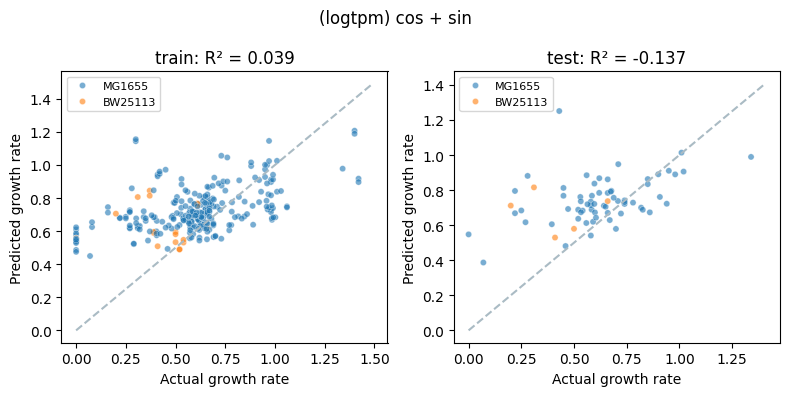

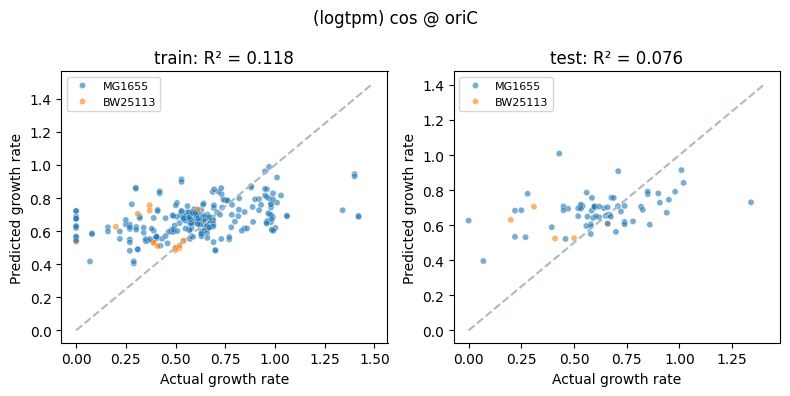

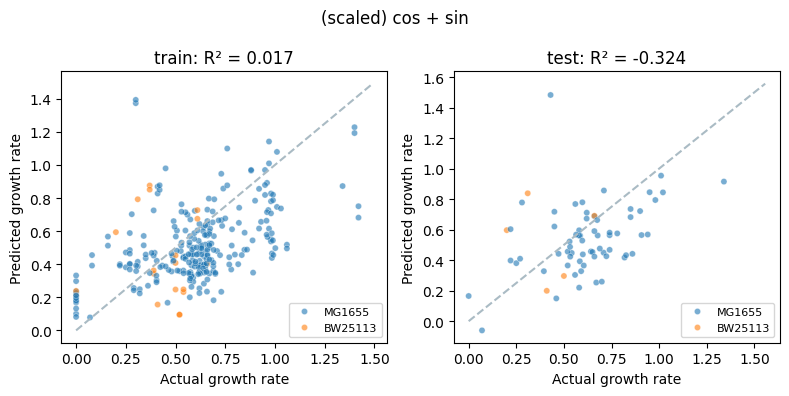

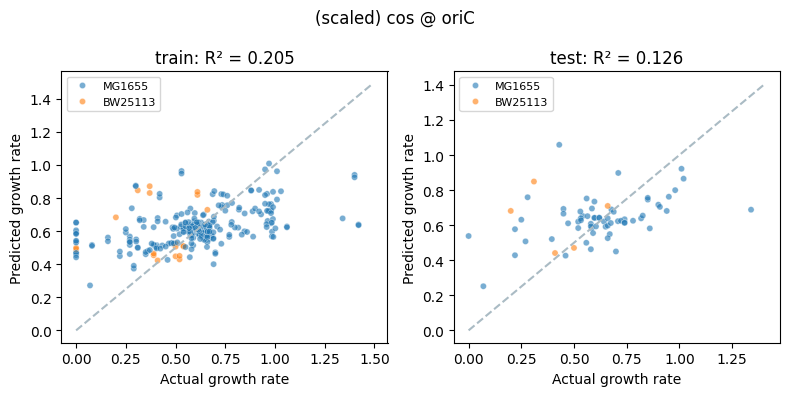

In [56]:
for (normalization, terms_label), f in fitted.items():
    plot_predicted_vs_actual_grid([
        {"y": f["train"]["Growth Rate (1/hr)"], "pred": f["train_pred"], "label": "train", "strain": f["train"]["strain"]},
        {"y": f["test"]["Growth Rate (1/hr)"],  "pred": f["test_pred"],  "label": "test",  "strain": f["test"]["strain"]},
    ], title = f"({normalization}) {terms_label}", ncols = 2)

Visual inspection of the results confirms the poor predictive performance of all fitted models. A common pattern that can be noticed is that regression tends to respectively over-predict and under-predict growth rate measurements below or above ~0.65. Since most annotated samples have a growth rate of around such value, as seen in sections 3.3 and 3.4, this effect is likely due to a scarce contribution of fitted harmonics parameters in the actual measure of growth rate.

### **Conclusions**

* Overall, the predictive performance is very poor across all tested models (maximum test R² score ≈ 0.13). This limitation is likely due to growth rate dependant effects which do not emerge solely from gene locations inside the chromosome.

* Coefficients of harmonics model fitted on filtered and scaled data show higher regression performance compared to logTPM ones. This, along with the observations in section 4 regarding the better harmonics models fitting performance on scaled data, confirms our design choice of considering them as an alternative preprocessing approach.

* Coefficients of `cos @ oriC` models lead to better results compared to those of the full harmonics ones, especially on test sets. This could be due to a possible increased noise which `cos + sin` models present in peak position prediction, which would contribute to overfitting on the training data.

# 6. Gene-specific growth rate regression

After obtaining poor results in growth rate prediction from harmonics model fitting parameters, we decided to explore alternative approaches for the task. We hypothesised that the low performance was a result of a wrong assumption of considering the effect of all genes equally, only based on their position on the chromosome. To try and solve this, we attempted to model each gene's own impact on growth rate regression using neural network models, taking as input a dimensionality reduction of the whole expression space.

## 6.1. Growth rate MLP regression

In this section, we will try to regress over growth rate by training a multilayer perceptron (MLP) on gene expression data, without taking into consideration positional information inside the chromosome.

Since we will scale expression data in a subsequent step to perform PCA, we will start from normalized expression data. In order to avoid overfitting, we will keep only the genes selected for the scaling step, that is, the ones whose variance exceeds a certain thershold across the various strains of interest.

First we prepare the functions necessary to prepare the data for fitting. We extract $log_2(TPM)$ and growth rate data from the samples that have one annotated. Only strains with a reasonable amount of annotated samples (in this case, 20) are kept.

In [57]:
def build_mlp_dataset(exprs_dict, samples_str):

    # Only keep strains that have at least 20 annotated sample
    valid_strains = [strain for strain in exprs_dict
                     if strain in samples_str.keys() and len(samples_str[strain]) >= 20]
    skipped = set(exprs_dict) - set(valid_strains)
    if skipped:
        print(f"Skipping strains with amount of annotated growth rate samples < 20: {sorted(skipped)}")

    common_genes = set.intersection(*[set(exprs_dict[strain].index) for strain in valid_strains])
    common_genes = sorted(common_genes)
    print(f"{len(common_genes)} genes common across {len(valid_strains)} strains: {valid_strains}")

    X_parts, y_parts, strain_parts = [], [], []

    for strain in valid_strains:
        e_str = exprs_dict[strain]
        gr = samples_str[strain]["Growth Rate (1/hr)"]

        sample_ids = e_str.columns.intersection(gr.index)
        X_strain = e_str.loc[common_genes, sample_ids].T
        y_strain = gr.loc[sample_ids]

        X_parts.append(X_strain)
        y_parts.append(y_strain)
        strain_parts.append(pd.Series(strain, index = sample_ids))

    X = pd.concat(X_parts)
    y = pd.concat(y_parts)
    strain_labels = pd.concat(strain_parts)

    return X, y, strain_labels

X, y, strain = build_mlp_dataset(exprs_logtpm_str_sub, samples_str_ann)

print(f"Dataset shape: {X.shape}")

Skipping strains with amount of annotated growth rate samples < 20: ['DGF-298', 'GMOS', 'W3110']
3569 genes common across 2 strains: ['MG1655', 'BW25113']
Dataset shape: (345, 3569)


We proceed by splitting the dataset into training, validation and test sets, with a $3:1:1$ ratio. Compared to the growth rate regression model we previously built from harmonics fittings, a validation set is now needed in order to tune the neural network's hyperparameters; regardless of such difference, though, an equal size of test set was selected to have a proper comparison between the two approaches. We again stratify by strain and carbon source to avoid obtaining an unbalanced dataset.

In [58]:
def make_splits(X, y, strata,
                test_size = 0.2,
                val_size = 0.2,
                random_state = 42):
    
    X_train_val, X_test, y_train_val, y_test, strata_train_val, _ = train_test_split(
        X, y, strata,
        test_size = test_size,
        random_state = random_state,
        stratify = strata
    )
    relative_val_size = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size = relative_val_size,
        random_state = random_state,
        stratify = strata_train_val
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

strata = build_strata(strain, samples_str)

X_train, X_val, X_test, y_train, y_val, y_test = make_splits(
    X, y, strata,
    random_state = random_state
)

print(f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

8 strata after pooling rare combinations (min_count = 6)
train: 207, val: 69, test: 69


The amount of total genes vastly overnumber that of total samples. To avoid overfitting, dimensionality reduction via the selection of the first 20 principal components of PCA has been performed. The values of each principal component will be given as inputs to the MLP architecture in the following steps.

In [59]:
def preprocess_features(X_train, X_val, X_test,
                        n_components = 20,
                        random_state = 42):

    # Scale data with training set as reference
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    # Perform PCA
    pca = PCA(n_components = n_components,
              random_state = random_state)
    
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    X_test_p = pca.transform(X_test_s)

    print(f"Explained variance with {n_components} components: {pca.explained_variance_ratio_.sum():.2%}")
    return X_train_p, X_val_p, X_test_p, scaler, pca

X_train_p, X_val_p, X_test_p, scaler, pca = preprocess_features(
    X_train, X_val, X_test,
    n_components = 20,
    random_state = random_state
)

Explained variance with 20 components: 77.72%


With 20 principal components, we are able to explain more than 75% of the total variance of the dataset.

We proceed by constructing the architecture for the neural network regressor. A model with a single hidden layer has been deemed flexible enough for the task, without having an amount of weights high enough to make the MLP memorize the training dataset. Loss function was chosen to be Mean Squared Error (MSE), activation function the Rectified Linear unit (ReLu), and solver Adam.

In [60]:
def train_mlp(X_train, y_train, X_val, y_val,
              hidden_size = 8,
              alpha = 1.0,
              random_state = 42):
    
    mlp = MLPRegressor(
        hidden_layer_sizes = (hidden_size,),
        alpha = alpha,
        activation = "relu",
        max_iter = 10_000,
        early_stopping = True,
        n_iter_no_change = 20,
        random_state = random_state
    )
    mlp.fit(X_train, y_train)

    val_pred = mlp.predict(X_val)
    val_r2 = r2_score(y_val, val_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    return mlp, val_r2, val_mse

In order to enstablish some hyperparameter values fit for the task, we sweep across various combination of hidden layer size and alpha (L2 regularization term) and select the ones with best results on the validation set.

In [61]:
def sweep_hyperparams(X_train, y_train, X_val, y_val,
                      hidden_sizes = [8],
                      alphas = [1.0],
                      random_state = 42):
    
    results = []
    for h in hidden_sizes:
        for a in alphas:
            mlp, r2, mse = train_mlp(X_train, y_train, X_val, y_val,
                                     hidden_size = h,
                                     alpha = a,
                                     random_state = random_state)
            results.append({"hidden_size": h, "alpha": a, "val_r2": r2, "val_mse": mse})
    return pd.DataFrame(results).sort_values("val_r2", ascending = False)

sweep = sweep_hyperparams(
    X_train_p, y_train, X_val_p, y_val,
    hidden_sizes = [8, 12, 16],
    alphas = [10.0, 30.0, 100.0],
    random_state = random_state
)
print(sweep)

   hidden_size  alpha    val_r2   val_mse
7           16   30.0  0.760824  0.016343
8           16  100.0  0.700776  0.020447
2            8  100.0  0.369766  0.043065
3           12   10.0  0.339789  0.045114
4           12   30.0  0.335103  0.045434
1            8   30.0 -0.342884  0.091762
6           16   10.0 -1.494666  0.170465
0            8   10.0 -2.582598  0.244806
5           12  100.0 -3.337005  0.296356


Most tested models show higher validation R² scores compared to the regression models obtained from linear modeling of harmonics fitting parameters. In particular, the best validation results are achieved with 16 neurons in the hidden layer and an L2 regularization term of 30, originating the following architecture (from top to bottom, input, hidden and output layers):

![MLP architecture](nn.png)

We can then proceed by selecting such architecture and training it once more by keeping trace of losses across epochs.

In [62]:
def train_mlp_with_history(X_train, y_train, X_val, y_val,
                           hidden_size = 8,
                           alpha = 1.0,
                           n_epochs = 500,
                           random_state = 42):
    
    mlp = MLPRegressor(
        hidden_layer_sizes = (hidden_size,),
        alpha = alpha,
        activation = "relu",
        max_iter = 1,
        warm_start = True,
        random_state = random_state
    )

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        mlp.partial_fit(X_train, y_train)
        train_pred = mlp.predict(X_train)
        val_pred = mlp.predict(X_val)
        train_losses.append(mean_squared_error(y_train, train_pred))
        val_losses.append(mean_squared_error(y_val, val_pred))

    return mlp, train_losses, val_losses

best = sweep.iloc[0]
mlp_hist, train_losses, val_losses = train_mlp_with_history(
    X_train_p, y_train, X_val_p, y_val,
    hidden_size = int(best["hidden_size"]),
    alpha = best["alpha"],
    random_state = random_state
)

We can visualize losses throughout training epochs for samples of both sets.

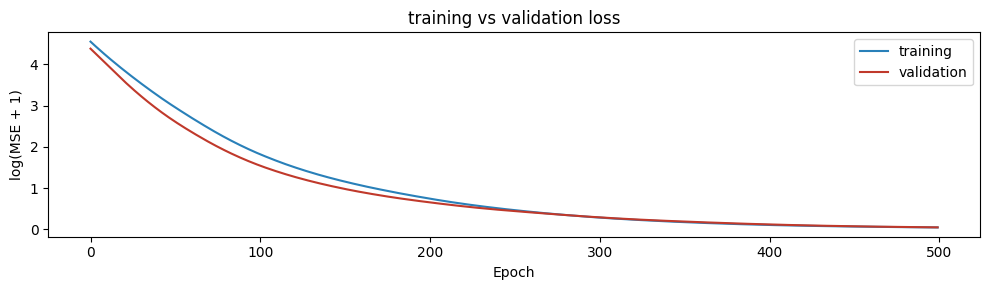

In [63]:
# Plot traning and validation loss
fig, ax = plt.subplots(figsize = (10, 3))
ax.plot(np.log1p(train_losses), label = "training", color = "#2980B9")
ax.plot(np.log1p(val_losses), label = "validation", color = "#C0392B")
ax.set_xlabel("Epoch")
ax.set_ylabel("log(MSE + 1)")
ax.set_title("training vs validation loss")
ax.legend()

plt.tight_layout()
plt.show()

We observe how both losses converge after around 400 epochs. Interestingly, validation loss is consitently lower than the training one in early epochs, and does not appear to change its monotonic descent in later ones. This suggests that the model is actually learning good general information for predicting growth rate from PCA components, and not just memorizing annotated measures from the training dataset.

After training, we can move onto evaluation of prediction performance on the test set, to confirm whether this approach leads to better results compared to the harmonics fitting one.

In [64]:
def evaluate_final(X_train, y_train, X_val, y_val, X_test, y_test,
                   hidden_size = 8,
                   alpha = 1.0,
                   random_state = 42):
    
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = pd.concat([y_train, y_val])

    mlp = MLPRegressor(
        hidden_layer_sizes = (hidden_size,),
        alpha = alpha,
        activation = "relu",
        max_iter = 10_000,
        early_stopping = True,
        n_iter_no_change = 20,
        random_state = random_state
    )
    mlp.fit(X_trainval, y_trainval)

    test_pred = mlp.predict(X_test)
    test_r2 = r2_score(y_test, test_pred)

    return mlp, test_pred, test_r2

mlp_final, test_pred, test_r2 = evaluate_final(
    X_train_p, y_train, X_val_p, y_val, X_test_p, y_test,
    hidden_size = int(best["hidden_size"]),
    alpha = best["alpha"],
    random_state = random_state
)
print(f"test R² = {test_r2:.3f} (hidden_size = {int(best["hidden_size"])}, alpha = {best["alpha"]})")

test R² = 0.826 (hidden_size = 16, alpha = 30.0)


Indeed, we obtain a considerably high R² score also on test set samples.

We can again observe predicted vs actual growth rate measures on the various sets, this time also including the additional validation dataset generated for the analysis.

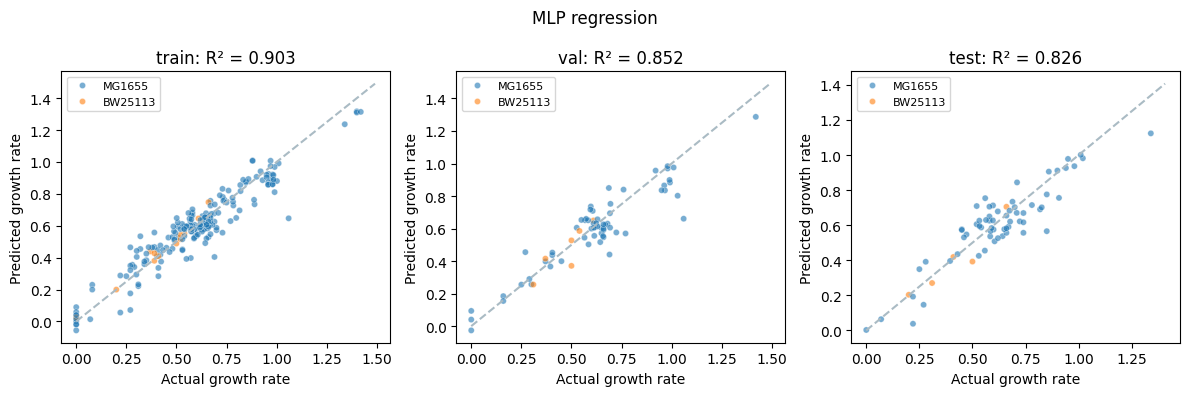

In [65]:
train_pred = mlp_final.predict(np.vstack([X_train_p, X_val_p])[:len(X_train_p)])
val_pred = mlp_final.predict(X_val_p)

plot_predicted_vs_actual_grid([
    {"y": y_train, "pred": train_pred, "label": "train", "strain": strain.loc[y_train.index]},
    {"y": y_val,   "pred": val_pred,   "label": "val",   "strain": strain.loc[y_val.index]},
    {"y": y_test,  "pred": test_pred,  "label": "test",  "strain": strain.loc[y_test.index]},
], title = "MLP regression", ncols = 3)

In all three samples sets, predicted growth rate values line up nicely with the annotated ones. In particular, there does not appear to be a strong bias in the predicted measurements, as growth rates considerably different from ~0.65 do not seem to get predicted considerably worse than the others.

## 6.2. MLP model interpretability

In this final section, we will try to give an interpretation of the information learned by the neural network in order to regress over growth rate.

By analysing the gradient of the output with respect to each input we can have an idea of how much and in which direction each input contributes to the result.

In [66]:
def mlp_gradient(mlp, X):

    W1, W2 = mlp.coefs_[0], mlp.coefs_[1]
    b1 = mlp.intercepts_[0]
    z1 = X @ W1 + b1

    # Make sure activation function is ReLu
    assert mlp.activation == "relu"

    # ReLu derivative
    d_act = (z1 > 0).astype(float)

    grad = (d_act * W2.ravel()) @ W1.T
    
    return grad

Since the actual input of the MLP are principal components rather than gene expression data, we also need to retrieve it from PCA and scaling information.

In [67]:
def project_gradient_to_genes(grad_pca, pca, scaler):

    # Get scaled expression from principal components
    grad_scaled_gene = grad_pca @ pca.components_

    # Get centered logTPM expression from scaled expression
    grad_raw_gene = grad_scaled_gene / scaler.scale_

    return grad_raw_gene

We can then compute regression relevance and direction for each gene in our filtered expression matrix.

In [68]:
def compute_gene_attribution(mlp, X_pca, pca, scaler, gene_names):
    
    grad_pca = mlp_gradient(mlp, X_pca)
    grad_genes = project_gradient_to_genes(grad_pca, pca, scaler)

    attribution = pd.DataFrame({
        "gene_id": gene_names,
        "importance": np.abs(grad_genes).mean(axis = 0),
        "direction": grad_genes.mean(axis = 0),
    }).set_index("gene_id")

    return attribution

gene_attribution = compute_gene_attribution(
    mlp_final, X_train_p, pca, scaler, X.columns
)
print("Most relevant up-directional genes")
print(gene_attribution[gene_attribution["direction"] > 0].sort_values("importance", ascending = False).head(5))

print("\nMost relevant down-directional genes")
print(gene_attribution[gene_attribution["direction"] < 0].sort_values("importance", ascending = False).head(5))

Most relevant up-directional genes
         importance  direction
gene_id                       
b3860      0.002769   0.002769
b0154      0.002482   0.002466
b3649      0.002429   0.002397
b3641      0.002155   0.002121
b3640      0.002061   0.002027

Most relevant down-directional genes
         importance  direction
gene_id                       
b2067      0.001708  -0.001707
b1624      0.001617  -0.001601
b2329      0.001436  -0.000926
b0446      0.001430  -0.001428
b2176      0.001428  -0.001028


Just from this initial inspection, we can observe how the most relevant genes tends to be up-directional (*i.e.*, genes for which an increase in expression will generally contribute to an increase in growth rate prediction in our MLP model).

Finally, we can match the genes to their original position in the MG1655 genome in order to visualize their location across the chromosome.

In [69]:
mg1655_gene_pos = ref_builds["MG1655"]["gene_pos"]
genome_length = ref_builds["MG1655"]["genome_length"]

gene_attribution = gene_attribution.join(mg1655_gene_pos[[ref_pos]], how = "inner")
gene_attribution["rad"] = 2 * np.pi * gene_attribution[ref_pos] / genome_length

print(f"{len(gene_attribution)} of {len(X.columns)} genes matched to MG1655 positions")

3479 of 3569 genes matched to MG1655 positions


We visualize each gene in the circular chromosome, assigning their distance from the center of the plot as the regression relevance and their color as the direction. In summary, increasing values of a gene in red will tend to bring predicted growth rate up; vice versa, increasing values of a gene in blue will tend to bring predicted growth rate down.

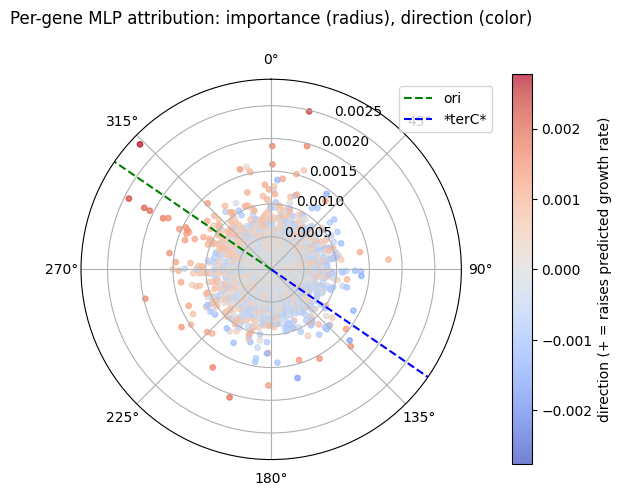

In [70]:
fig, ax = plt.subplots(figsize = (6, 6), subplot_kw = {"projection": "polar"})

ori_rad = ref_builds["MG1655"]["ori_rad"]
ter_rad = ref_builds["MG1655"]["ter_rad"]
ax.axvline(ori_rad, color = "green", ls = "--", lw = 1.5, label = "ori")
ax.axvline(ter_rad, color = "blue", ls = "--", lw = 1.5, label = "*terC*")

max_abs_dir = gene_attribution["direction"].abs().max()
sc = ax.scatter(
    gene_attribution["rad"], gene_attribution["importance"],
    c = gene_attribution["direction"], cmap = "coolwarm",
    vmin = -max_abs_dir, vmax = max_abs_dir,
    s = 15, alpha = 0.7
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Per-gene MLP attribution: importance (radius), direction (color)\n")
fig.colorbar(sc, ax = ax, label = "direction (+ = raises predicted growth rate)", pad = 0.1, shrink = 0.7)
ax.legend(loc = "upper right", bbox_to_anchor = (1.1, 1))

plt.tight_layout()
plt.show()

We can observe how the most relevant genes in raising predicted growth rate are located near the origin of replication, consistently with what we expect from the theoretical framework of this project. Interestingly, the most relevant genes appear to be located in between *oriC*/*terC* and the 90°/270° axis, hinting at a possible explanation of `sin @ start` harmonics model good performance in growth rate correlation, as seen in section 5.3. It is important to note that regression contribution is not spread as evenly as a windowing approach would suggest, as it appears that genes with contrasting directions are intermixed throughout the chromosome. This would suggest that gene-specific function also plays an important role in predicting growth rate, rather than genomic position alone.

As an additional consideration for this last point, we noticed how growth rate and carbon source were highly correlated. Genes with a functional role in the metabolism of one or the other, that may be activated or repressed in different environments independently on their genomic position, may have high relevance in predicting growth rate in this specific context.

# 7. Discussion

**What did the analyses show?**

The results from this project support the idea that DNA replication patterns are detectable in the E.coli transcriptome also in bulk RNA-sequencing data where the gene expression signal is expected to be averaged over cells. From the models we tested, the *oriC*-aligned cosine model revealed a significant gradient in 65/582 samples in the MG1655 cohort. The pattern of significance of all the five models is indicating that the gradient seems to be genuinely aligned with the origin-terminus axis (*oriC*/*terC*). The cosine models find more significant samples compared to the sine models and we can see that these samples frequently fall within the shaded regions in the polar plots. The direction of the gradient ($\beta$) seems to be more informative than the amplitude alone. We observe that the fast growing bacteria show a positive beta, and negative beta may appear due to slow growing or stressed cells as mentioned above. The idea is that the replication leads to *oriC*-peak and this signal should scale with growth rate. When there is no replication or slow replication, the gradient may disappear or possibly even lead to upregulation of genes near *terC*.

**The Helmstetter-Cooper comparison:**

We observed a fitted slope of 0.846 hours, which is close to the expected 0.96 hours from the Helmstetter-Cooper theory. As mentioned in section 5.2, this small difference between the two values seems reasonable due to variations in DNA copy numbers and mRNA levels. Another reason may be the fact that mRNA is constantly being broken down and replaced, which may impact observations of changes caused by DNA replication. Overall, the bulk data reflects a more complex picture than with scRNA-seq data. We can argue that seeing some kind of effect in the bulk data is already a good sign and may indicate an effect that is solid enough to overcome all these factors of noise.

**The MLP did better for growth rate prediction, why is that?**

Because the harmonic model only captures the chromosome-scale gradient and we know that growth rate affects the gene expression across the genome in many ways at the same time, MLP was useful in this case. The PCA components (20 PCs) of the expression matrix explains many more variables, not just the replication gradient. The MLP model is able to use all these signals to learn. We see from the interpretability analysis that the most important genes are actually distributed across the whole chromosome and not just close to the origin. The network was able to learn the entire expression programme that was correlated to the growth-rate rather than just the idea of genes near the origin have a higher expression at faster growth rates.

## 7.1 Limitations

1. Bulk RNA-seq vs. scRNA-seq data
    - The previous effect shown in Pountain et al. (2022) was found using scRNA-seq where the measurements are from each individual cell at a specific time point. Instead in this analyses we use bulk RNA-seq data which averages the expression of millions of cells where they are at different time points of growth. So the copy-number gradient from any cell has been averaged out across the whole population and this weakens the signal and detection power. This could mean that the effect we found in this project may be smaller than what is possible to find with scRNA-seq data.

2. Data consists of mostly moderate or slow growth rates 
    - We do observe that the growth rate in this data set is skewed towards moderate to slow growth rates. Since the replication-gradient should be strongest in faster growing bacteria where the overlapping rounds of replications are more prominent, we may not be able to capture the strongest effect in this project.

3. logTPM as a measurment of expression
    - From Helmstetter-Cooper the predictions are about DNA copy numbers. Here the measure is mRNA levels that has been normalized by depth of sequencing and gene length. As mentioned previously, factors like transcriptional regulation, normalization and mRNA stability may interfere with the information about true expression levels.

4. Gene identifiers for BW25113
    - Because the GFF annotation of the BW25113 cohort uses strain-specific locus tags, another step is needed to translate from gene symbols to MG1655 b-numbers. We can only do this step if genes have an annotation in both strains. If there is no shared symbol between the strains we lose the gene in this step. This can be why BW25113 maps to fewer genes compared to MG1655. In this step we could possibly lose genes that are important for detecting a real signal. It may be possible to imply that this fact is not a big problem in this project by looking at the gene density plot that is relatively uniform.

5. Growth rate regression for unannotated samples
    - In the assignment, it is stated that one possible task could be that of regressing growth rate for those samples for which it is not reported. However, across the various growth rate regression sections, we chose not to consider such samples, since we would not have any way to actually verify the accuracy of said predictions. Given the fact that prediction using harmonic model fitting results shows poor performance on annotated data, we ultimately did not include regression on unannotated samples.

6. Low amount of samples both significant and annotated
    - Across all samples tested for harmonics model fit, only a handful of the significant ones also presented a growth rate measurement. Although it would have conceptually made more sense to only perform growth rate regression on samples both significant and annotated (which, in separate tests, also gave better results than the currently reported predictions), the scarce amount (~30 samples) lead us to perform the analyses in section 5 on all annotated samples.

## 7.2. Conclusions

Overall we are able to show that an expression gradient driven by DNA replication can be detected in bulk E.coli RNA-seq data by using harmonic regression models on genomic windows although the effect is slight. From the different models, the *oriC*-aligned cosine model was the most sensitive and detected significant gradient in 65/582 (or 11%) of MG1655 samples. Further we predicted a slope of 0.846 hours for the expression gradient vs. growth rate. This slope is quite close to the predicted slope of 0.96 hours from Helmstetter-Cooper theory and supports the idea that replication copy number is what drives the pattern we observe.

Prediction of growth rate from the two-parameter harmonic fit gave us at most an R² ≈ 0.126 on the test set. When applying a more complex MLP that was trained on PCA-reduced genome wide expression, we achieved an R² of ≈ 0.826 on a test set.

These results support replication-driven copy-number variation is a detectable feature even in the E.coli transcriptome bulk data. By using genome-wide expression it seems to be possible to predict the growth rate with a higher accuracy.

---

# References

* Cooper, S., & Helmstetter, C. E. (1968). Chromosome replication and the division cycle of
*Escherichia coli* B/r. *Journal of Molecular Biology*, 31(3), 519–540.

* Pountain, A. W., Jiang, P., Podkowik, M., Shopsin, B., Torres, V. J., & Yanai, I. (2022).
A quantitative model for the transcriptional landscape of the bacterial cell cycle. *bioRxiv*.
https://doi.org/10.1101/2022.10.22.513359

* Genome references source: https://www.ncbi.nlm.nih.gov/datasets/genome/